# Analisi delle Repository relative ai Context File

Notebook per analizzare `git_history_diffs.json` con:
1. Grafico globale degli status dei context file.
2. Sezioni per ogni repository con contributor, top commit context-file e commit con più modifiche.

In [22]:
import json
from pathlib import Path
import re
import os
import urllib.request
import urllib.error
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

plt.style.use('seaborn-v0_8-whitegrid')

json_candidates = [
    Path(r"D:\\Progetti\\ContextWare\\data-manipulation\\outputs\\git_history_diffs.json"),
    Path("../../outputs/git_history_diffs.json"),
    Path("../outputs/git_history_diffs.json"),
    Path("outputs/git_history_diffs.json"),
]

json_path = next((p for p in json_candidates if p.exists()), None)
if json_path is None:
    raise FileNotFoundError("File git_history_diffs.json non trovato")

with json_path.open(encoding="utf-8") as f:
    raw_data = json.load(f)

rows = []
for repo_item in raw_data:
    repo = repo_item.get("repo")
    for commit in repo_item.get("acf_commits", []):
        commit_hash = commit.get("hash")
        commit_url = commit.get("url")
        for acf_file in commit.get("acf_files", []):
            rows.append({
                "repo": repo,
                "hash": commit_hash,
                "url": commit_url,
                "author": commit.get("commit_author", ""),
                "date": commit.get("commit_date", ""),
                "message": commit.get("commit_message", ""),
                "filename": acf_file.get("filename"),
                "status": acf_file.get("status"),
                "additions": acf_file.get("additions", 0),
                "deletions": acf_file.get("deletions", 0),
                "changes": acf_file.get("changes", 0),
            })

acf_df = pd.DataFrame(rows)
if acf_df.empty:
    raise ValueError("Nessun dato ACF trovato nel file JSON")

repo_history_dir = json_path.parent / "repo_history"
history_pattern = re.compile(r"^(?P<hash>[0-9a-f]{40}) \| (?P<date>[^|]+) \| (?P<author>[^|]+) \| (?P<message>.*) \| (?P<url>https?://.*)$")

history_rows = []
def read_lines_with_fallback(path: Path):
    data = path.read_bytes()
    best_text = None
    best_errors = None
    for enc in ("utf-8", "utf-8-sig", "cp1252", "latin-1"):
        try:
            text = data.decode(enc)
        except UnicodeDecodeError:
            text = data.decode(enc, errors="replace")
        errors = text.count(chr(0xFFFD))
        if best_errors is None or errors < best_errors:
            best_text = text
            best_errors = errors
            if errors == 0:
                break
    return best_text.splitlines() if best_text is not None else []

if repo_history_dir.exists():
    for txt_file in repo_history_dir.glob("*.txt"):
        repo_name = txt_file.stem.replace("__", "/")
        for line in read_lines_with_fallback(txt_file):
            line = line.strip()
            m = history_pattern.match(line)
            if m:
                item = m.groupdict()
                item["repo"] = repo_name
                history_rows.append(item)

history_df = pd.DataFrame(history_rows)
if not history_df.empty:
    history_df = history_df[["repo", "hash", "date", "author", "message", "url"]]
else:
    history_df = pd.DataFrame(columns=["repo", "hash", "date", "author", "message", "url"])

def clean_text(text):
    if pd.isna(text):
        return text
    text = str(text)
    text = text.replace(chr(0xFFFD), "")
    text = " ".join(text.split())
    return text

if not history_df.empty:
    history_df["message"] = history_df["message"].apply(clean_text)
    history_df["author"] = history_df["author"].apply(clean_text)

def load_env_files(paths):
    for path in paths:
        if not os.path.exists(path):
            continue
        with open(path, "r", encoding="utf-8") as handle:
            for raw in handle:
                line = raw.strip()
                if not line or line.startswith("#") or "=" not in line:
                    continue
                key, value = line.split("=", 1)
                key = key.strip()
                value = value.strip().strip('"').strip("'")
                if key and key not in os.environ:
                    os.environ[key] = value


def fetch_commit_info(owner, repo, sha, token):
    url = f"https://api.github.com/repos/{owner}/{repo}/commits/{sha}"
    headers = {
        "Accept": "application/vnd.github+json",
        "X-GitHub-Api-Version": "2022-11-28",
        "User-Agent": "contextware-report",
    }
    if token:
        headers["Authorization"] = f"Bearer {token}"
    req = urllib.request.Request(url, headers=headers)
    try:
        with urllib.request.urlopen(req) as resp:
            body = resp.read().decode("utf-8")
    except urllib.error.HTTPError:
        return None
    data = json.loads(body) if body else {}
    commit = data.get("commit") or {}
    author = commit.get("author") or {}
    committer = commit.get("committer") or {}
    date = author.get("date") or committer.get("date") or ""
    name = author.get("name") or committer.get("name") or ""
    message = (commit.get("message") or "").splitlines()[0]
    return {"message": message, "author": name, "date": date}


def refresh_messages_for_repo(history_df, repo_name, hashes, token_env="GITHUB_TOKEN"):
    if not hashes:
        return history_df
    load_env_files([".env", os.path.join(".contextWare", ".env")])
    token = os.environ.get(token_env)
    owner, repo = repo_name.split("/", 1)

    repo_rows = history_df[history_df["repo"] == repo_name]
    existing_messages = dict(zip(repo_rows["hash"], repo_rows["message"]))

    targets = []
    for sha in hashes:
        msg = existing_messages.get(sha)
        if msg is None:
            targets.append(sha)
            continue
        if str(msg).count("?") >= 3:
            targets.append(sha)

    if not targets:
        return history_df

    for sha in targets:
        info = fetch_commit_info(owner, repo, sha, token)
        if not info:
            continue
        message = clean_text(info.get("message"))
        author = clean_text(info.get("author"))
        date = clean_text(info.get("date"))
        mask = (history_df["repo"] == repo_name) & (history_df["hash"] == sha)
        if mask.any():
            if message:
                history_df.loc[mask, "message"] = message
            if author:
                history_df.loc[mask, "author"] = author
            if date:
                history_df.loc[mask, "date"] = date
        else:
            history_df = pd.concat(
                [
                    history_df,
                    pd.DataFrame(
                        [
                            {
                                "repo": repo_name,
                                "hash": sha,
                                "date": date,
                                "author": author,
                                "message": message,
                                "url": f"https://github.com/{repo_name}/commit/{sha}",
                            }
                        ]
                    ),
                ],
                ignore_index=True,
            )

    return history_df


# Fix mojibake in bannzai repo messages by re-fetching from GitHub.
bannzai_repo = "bannzai/SwiftTUI"
bannzai_hashes = (
    acf_df.loc[acf_df["repo"] == bannzai_repo, "hash"].dropna().unique().tolist()
)
if bannzai_hashes:
    history_df = refresh_messages_for_repo(history_df, bannzai_repo, bannzai_hashes)

commit_context_df = (
    acf_df.groupby(["repo", "hash", "url"], as_index=False)
    .agg(
        context_files=("filename", "count"),
        additions=("additions", "sum"),
        deletions=("deletions", "sum"),
        changes=("changes", "sum"),
        author=("author", "first"),
        date=("date", "first"),
        message=("message", "first"),
    )
)

for col in ("author", "date", "message"):
    commit_context_df[col] = commit_context_df[col].replace("", None).fillna("N/A")

display(Markdown(f"**Sorgente dati:** `{json_path}`"))
display(Markdown(f"**Repository analizzate:** {acf_df['repo'].nunique()}"))

**Sorgente dati:** `..\..\outputs\git_history_diffs.json`

**Repository analizzate:** 21

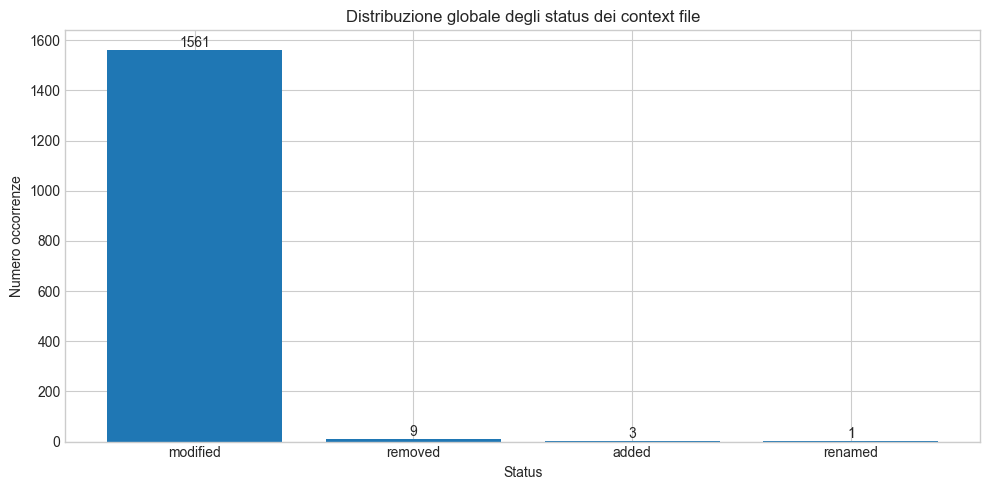

,count
status,
modified,1561
removed,9
added,3
renamed,1


In [23]:
status_counts = acf_df["status"].value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(status_counts.index, status_counts.values)
ax.set_title("Distribuzione globale degli status dei context file")
ax.set_xlabel("Status")
ax.set_ylabel("Numero occorrenze")
ax.bar_label(bars)
plt.tight_layout()
plt.show()

display(status_counts.rename_axis("status").to_frame("count"))

In [24]:
def show_repo_report(repo_name: str, top_n: int = 10):
    display(Markdown(f"## {repo_name}"))

    repo_commits = commit_context_df[commit_context_df["repo"] == repo_name].copy()
    if repo_commits.empty:
        display(Markdown("Nessun commit context-file trovato."))
        return

    display(Markdown("### Contributor nella repository"))
    if not history_df.empty:
        repo_contributors = (
            history_df[history_df["repo"] == repo_name]["author"]
            .value_counts()
            .head(top_n)
            .sort_values(ascending=True)
        )
        if not repo_contributors.empty:
            fig, ax = plt.subplots(figsize=(10, max(3, len(repo_contributors) * 0.45)))
            bars = ax.barh(repo_contributors.index, repo_contributors.values)
            ax.set_title(f"Top contributor per commit - {repo_name}")
            ax.set_xlabel("Numero commit nella repository")
            ax.set_ylabel("Contributor")
            ax.bar_label(bars)
            plt.tight_layout()
            plt.show()
        else:
            display(Markdown("Nessun contributor trovato."))
    else:
        display(Markdown("Dati contributor non disponibili (repo_history mancante)."))

    display(Markdown("### Top commit relativi ai context file (per numero di context file toccati)"))
    top_context_commits = (
        repo_commits.sort_values(["context_files", "changes"], ascending=False)
        [["hash", "author", "date", "context_files", "additions", "deletions", "changes", "message", "url"]]
        .head(top_n)
        .reset_index(drop=True)
    )
    with pd.option_context('display.max_colwidth', None, 'display.max_rows', None, 'display.width', None):
        display(top_context_commits)

    display(Markdown("### Commit context-file con maggiori modifiche (additions + deletions)"))
    top_changes = (
        repo_commits.sort_values("changes", ascending=False)
        [["hash", "author", "date", "changes", "additions", "deletions", "context_files", "message", "url"]]
        .head(top_n)
        .reset_index(drop=True)
    )
    with pd.option_context('display.max_colwidth', None, 'display.max_rows', None, 'display.width', None):
        display(top_changes)

In [25]:
show_repo_report("BMPixel/cui")

## BMPixel/cui

### Contributor nella repository

Nessun contributor trovato.

### Top commit relativi ai context file (per numero di context file toccati)

,hash,author,date,context_files,additions,deletions,changes,message,url
0,87661fbc95c7b0ae380988b63a2047e90f135458,bmpixel,2025-06-20T13:40:05Z,1,38,579,617,Add multiple CLAUDE.md,https://github.com/wbopan/cui/compare/adfc2f06667c4f89fb69001f5c32d5fcac6342b9...87661fbc95c7b0ae380988b63a2047e90f135458
1,d4009e36b9b07390f403e1f1e4f6f9433aae4de3,bmpixel,2025-06-17T12:38:50Z,1,17,569,586,"Remove MCP, continue endpoint and rewrite tests",https://github.com/wbopan/cui/compare/9a964d8e23f490c90fe92ca7b102a8b8352f51be...d4009e36b9b07390f403e1f1e4f6f9433aae4de3
2,adfc2f06667c4f89fb69001f5c32d5fcac6342b9,bmpixel,2025-06-20T13:21:22Z,1,477,49,526,Enhance API response clarity and add resume CLI command,https://github.com/wbopan/cui/compare/3a2390e038855487864e1baf0d3fc6a29072cb5e...adfc2f06667c4f89fb69001f5c32d5fcac6342b9
3,bd56bb3f8facc0ab95c79887ab5e73db930d3915,bmpixel,2025-06-12T11:47:47Z,1,503,16,519,Fix streaming integration tests with proper HTTP streaming approach,https://github.com/wbopan/cui/compare/6861081e970d14d25a9f527d114e292f8c5240d1...bd56bb3f8facc0ab95c79887ab5e73db930d3915
4,6f7ecdfff629b3515e12d50bd2860de806e710da,BMPixel,2025-07-11T07:23:40Z,1,3,283,286,Comment out auto refreshing,https://github.com/wbopan/cui/compare/9f75f31762cf71000e2995e7f41193767d1a8586...6f7ecdfff629b3515e12d50bd2860de806e710da
5,de7869736d7d8deee93f2f2b081cda999a7857e9,BMPixel,2025-07-22T03:53:15Z,1,67,160,227,Add and refine CLAUDE.md,https://github.com/wbopan/cui/compare/33a959c984894fff5ed5553dddb1134a621132e7...de7869736d7d8deee93f2f2b081cda999a7857e9
6,1eb89ca7e391d4ea65e625d824c00516d354edae,bmpixel,2025-06-18T05:55:18Z,1,163,15,178,Update unit tests and source code with comprehensive test coverage,https://github.com/wbopan/cui/compare/6e8f743d0ee5fa476c6b5bd622eb9cc6a0d60b11...1eb89ca7e391d4ea65e625d824c00516d354edae
7,a09cf067a8681c73e6ef6b07a8f995f7bc71e7ff,bmpixel,2025-08-07T03:06:29Z,1,75,98,173,tests: revert to jest tests,https://github.com/wbopan/cui/compare/68d3a6d90e6a2751007f764dbf90bde277231985...a09cf067a8681c73e6ef6b07a8f995f7bc71e7ff
8,83b64fd3517223d11ae0fc65264f9ed84d9a0be1,bmpixel,2025-06-19T01:34:46Z,1,70,0,70,Add resume conversation API endpoint,https://github.com/wbopan/cui/compare/a49989176405d659fb2c714078add15ad7d43b6a...83b64fd3517223d11ae0fc65264f9ed84d9a0be1
9,87c5a6e96954aeabaf8ac658261ac1fde417871a,bmpixel,2025-06-19T01:51:53Z,1,6,61,67,Add resume api endpoint,https://github.com/wbopan/cui/compare/83b64fd3517223d11ae0fc65264f9ed84d9a0be1...87c5a6e96954aeabaf8ac658261ac1fde417871a


### Commit context-file con maggiori modifiche (additions + deletions)

,hash,author,date,changes,additions,deletions,context_files,message,url
0,87661fbc95c7b0ae380988b63a2047e90f135458,bmpixel,2025-06-20T13:40:05Z,617,38,579,1,Add multiple CLAUDE.md,https://github.com/wbopan/cui/compare/adfc2f06667c4f89fb69001f5c32d5fcac6342b9...87661fbc95c7b0ae380988b63a2047e90f135458
1,d4009e36b9b07390f403e1f1e4f6f9433aae4de3,bmpixel,2025-06-17T12:38:50Z,586,17,569,1,"Remove MCP, continue endpoint and rewrite tests",https://github.com/wbopan/cui/compare/9a964d8e23f490c90fe92ca7b102a8b8352f51be...d4009e36b9b07390f403e1f1e4f6f9433aae4de3
2,adfc2f06667c4f89fb69001f5c32d5fcac6342b9,bmpixel,2025-06-20T13:21:22Z,526,477,49,1,Enhance API response clarity and add resume CLI command,https://github.com/wbopan/cui/compare/3a2390e038855487864e1baf0d3fc6a29072cb5e...adfc2f06667c4f89fb69001f5c32d5fcac6342b9
3,bd56bb3f8facc0ab95c79887ab5e73db930d3915,bmpixel,2025-06-12T11:47:47Z,519,503,16,1,Fix streaming integration tests with proper HTTP streaming approach,https://github.com/wbopan/cui/compare/6861081e970d14d25a9f527d114e292f8c5240d1...bd56bb3f8facc0ab95c79887ab5e73db930d3915
4,6f7ecdfff629b3515e12d50bd2860de806e710da,BMPixel,2025-07-11T07:23:40Z,286,3,283,1,Comment out auto refreshing,https://github.com/wbopan/cui/compare/9f75f31762cf71000e2995e7f41193767d1a8586...6f7ecdfff629b3515e12d50bd2860de806e710da
5,de7869736d7d8deee93f2f2b081cda999a7857e9,BMPixel,2025-07-22T03:53:15Z,227,67,160,1,Add and refine CLAUDE.md,https://github.com/wbopan/cui/compare/33a959c984894fff5ed5553dddb1134a621132e7...de7869736d7d8deee93f2f2b081cda999a7857e9
6,1eb89ca7e391d4ea65e625d824c00516d354edae,bmpixel,2025-06-18T05:55:18Z,178,163,15,1,Update unit tests and source code with comprehensive test coverage,https://github.com/wbopan/cui/compare/6e8f743d0ee5fa476c6b5bd622eb9cc6a0d60b11...1eb89ca7e391d4ea65e625d824c00516d354edae
7,a09cf067a8681c73e6ef6b07a8f995f7bc71e7ff,bmpixel,2025-08-07T03:06:29Z,173,75,98,1,tests: revert to jest tests,https://github.com/wbopan/cui/compare/68d3a6d90e6a2751007f764dbf90bde277231985...a09cf067a8681c73e6ef6b07a8f995f7bc71e7ff
8,83b64fd3517223d11ae0fc65264f9ed84d9a0be1,bmpixel,2025-06-19T01:34:46Z,70,70,0,1,Add resume conversation API endpoint,https://github.com/wbopan/cui/compare/a49989176405d659fb2c714078add15ad7d43b6a...83b64fd3517223d11ae0fc65264f9ed84d9a0be1
9,87c5a6e96954aeabaf8ac658261ac1fde417871a,bmpixel,2025-06-19T01:51:53Z,67,6,61,1,Add resume api endpoint,https://github.com/wbopan/cui/compare/83b64fd3517223d11ae0fc65264f9ed84d9a0be1...87c5a6e96954aeabaf8ac658261ac1fde417871a


In [26]:
show_repo_report("CIRISAI/CIRISAgent")

## CIRISAI/CIRISAgent

### Contributor nella repository

Nessun contributor trovato.

### Top commit relativi ai context file (per numero di context file toccati)

,hash,author,date,context_files,additions,deletions,changes,message,url
0,50a4e1de42a23c3e0153c53d90f994a60da9cb37,Eric,2025-06-25T04:32:02Z,1,520,339,859,"Major refactor: Eliminate Dict[str, Any] and achieve pytest green (#146)",https://github.com/CIRISAI/CIRISAgent/compare/2a5e717daad58a1469b1a89cfcd4c0946357a333...50a4e1de42a23c3e0153c53d90f994a60da9cb37
1,d0a86986389e1bc757cd10c219bd2ac519cb9d4f,Eric Moore,2025-06-29T22:44:37Z,1,82,611,693,refactor: rename ROOT to SYSTEM_ADMIN to avoid confusion with WA ROOT,https://github.com/CIRISAI/CIRISAgent/compare/8f9f68db9287410a3946990e2104757ebdf2eac2...d0a86986389e1bc757cd10c219bd2ac519cb9d4f
2,abe5d8b24ee559bf079ae3e59045fa691fa6ff93,Eric Moore,2025-06-16T15:21:06Z,1,82,448,530,"Zero Dict[str, Any] tolerance achieved + Identity profiles enriched",https://github.com/CIRISAI/CIRISAgent/compare/d63ab1822dfa36e92063237012ad80b98b22105f...abe5d8b24ee559bf079ae3e59045fa691fa6ff93
3,2a5e717daad58a1469b1a89cfcd4c0946357a333,Eric Moore,2025-06-20T15:02:55Z,1,270,26,296,"feat: redesign API to expose agent capabilities, not handlers",https://github.com/CIRISAI/CIRISAgent/compare/8bb08a326c2ee93aa827e83f328b9d924f1213c6...2a5e717daad58a1469b1a89cfcd4c0946357a333
4,825487b3f5c1a26ca481efe1527d06a32d9e7b52,Eric Moore,2025-06-19T04:09:27Z,1,95,170,265,feat: Complete BusManager refactoring and achieve pytest green,https://github.com/CIRISAI/CIRISAgent/compare/979a5b8b6d3d3493e28fdd8540521aec8c40383c...825487b3f5c1a26ca481efe1527d06a32d9e7b52
5,4b62d518de96fcc84c9b3a650ad3db02038661a5,Eric Moore,2025-06-16T15:32:48Z,1,179,82,261,"Update documentation for zero Dict[str, Any] achievement and agent profiles",https://github.com/CIRISAI/CIRISAgent/compare/abe5d8b24ee559bf079ae3e59045fa691fa6ff93...4b62d518de96fcc84c9b3a650ad3db02038661a5
6,b67929a8d3ad77a75b3678bb59b38edee847ad1e,Eric Moore,2025-08-03T20:54:35Z,1,34,204,238,refactor: Major cleanup and test integration for better coverage,https://github.com/CIRISAI/CIRISAgent/compare/051b8ec13193dd190259c6f76474929238fa0812...b67929a8d3ad77a75b3678bb59b38edee847ad1e
7,84826f2326179483b5a3946d7b2a0f933d881057,Eric Moore,2025-06-16T00:31:04Z,1,220,4,224,Complete OAuth API endpoints and identity system refactor,https://github.com/CIRISAI/CIRISAgent/compare/2e8516451811f513c59b889822a48c13010fa3e8...84826f2326179483b5a3946d7b2a0f933d881057
8,051b8ec13193dd190259c6f76474929238fa0812,Eric Moore,2025-08-01T23:11:48Z,1,65,73,138,Implement clean CD model with agent autonomy,https://github.com/CIRISAI/CIRISAgent/compare/2f81bf5e23954233c0e10c70870760aedaa3fe8c...051b8ec13193dd190259c6f76474929238fa0812
9,bdeed0bfe5c254c19856cdfaade5dc1d45ccd30f,Eric,2026-03-29T01:07:22Z,1,134,1,135,"Release 2.3.0: HA/MA Tool Documentation, Audit Trail Improvements (#650)",https://github.com/CIRISAI/CIRISAgent/compare/9d80d0300dad0872646bed5f1cda8feeb7668847...bdeed0bfe5c254c19856cdfaade5dc1d45ccd30f


### Commit context-file con maggiori modifiche (additions + deletions)

,hash,author,date,changes,additions,deletions,context_files,message,url
0,50a4e1de42a23c3e0153c53d90f994a60da9cb37,Eric,2025-06-25T04:32:02Z,859,520,339,1,"Major refactor: Eliminate Dict[str, Any] and achieve pytest green (#146)",https://github.com/CIRISAI/CIRISAgent/compare/2a5e717daad58a1469b1a89cfcd4c0946357a333...50a4e1de42a23c3e0153c53d90f994a60da9cb37
1,d0a86986389e1bc757cd10c219bd2ac519cb9d4f,Eric Moore,2025-06-29T22:44:37Z,693,82,611,1,refactor: rename ROOT to SYSTEM_ADMIN to avoid confusion with WA ROOT,https://github.com/CIRISAI/CIRISAgent/compare/8f9f68db9287410a3946990e2104757ebdf2eac2...d0a86986389e1bc757cd10c219bd2ac519cb9d4f
2,abe5d8b24ee559bf079ae3e59045fa691fa6ff93,Eric Moore,2025-06-16T15:21:06Z,530,82,448,1,"Zero Dict[str, Any] tolerance achieved + Identity profiles enriched",https://github.com/CIRISAI/CIRISAgent/compare/d63ab1822dfa36e92063237012ad80b98b22105f...abe5d8b24ee559bf079ae3e59045fa691fa6ff93
3,2a5e717daad58a1469b1a89cfcd4c0946357a333,Eric Moore,2025-06-20T15:02:55Z,296,270,26,1,"feat: redesign API to expose agent capabilities, not handlers",https://github.com/CIRISAI/CIRISAgent/compare/8bb08a326c2ee93aa827e83f328b9d924f1213c6...2a5e717daad58a1469b1a89cfcd4c0946357a333
4,825487b3f5c1a26ca481efe1527d06a32d9e7b52,Eric Moore,2025-06-19T04:09:27Z,265,95,170,1,feat: Complete BusManager refactoring and achieve pytest green,https://github.com/CIRISAI/CIRISAgent/compare/979a5b8b6d3d3493e28fdd8540521aec8c40383c...825487b3f5c1a26ca481efe1527d06a32d9e7b52
5,4b62d518de96fcc84c9b3a650ad3db02038661a5,Eric Moore,2025-06-16T15:32:48Z,261,179,82,1,"Update documentation for zero Dict[str, Any] achievement and agent profiles",https://github.com/CIRISAI/CIRISAgent/compare/abe5d8b24ee559bf079ae3e59045fa691fa6ff93...4b62d518de96fcc84c9b3a650ad3db02038661a5
6,b67929a8d3ad77a75b3678bb59b38edee847ad1e,Eric Moore,2025-08-03T20:54:35Z,238,34,204,1,refactor: Major cleanup and test integration for better coverage,https://github.com/CIRISAI/CIRISAgent/compare/051b8ec13193dd190259c6f76474929238fa0812...b67929a8d3ad77a75b3678bb59b38edee847ad1e
7,84826f2326179483b5a3946d7b2a0f933d881057,Eric Moore,2025-06-16T00:31:04Z,224,220,4,1,Complete OAuth API endpoints and identity system refactor,https://github.com/CIRISAI/CIRISAgent/compare/2e8516451811f513c59b889822a48c13010fa3e8...84826f2326179483b5a3946d7b2a0f933d881057
8,051b8ec13193dd190259c6f76474929238fa0812,Eric Moore,2025-08-01T23:11:48Z,138,65,73,1,Implement clean CD model with agent autonomy,https://github.com/CIRISAI/CIRISAgent/compare/2f81bf5e23954233c0e10c70870760aedaa3fe8c...051b8ec13193dd190259c6f76474929238fa0812
9,bdeed0bfe5c254c19856cdfaade5dc1d45ccd30f,Eric,2026-03-29T01:07:22Z,135,134,1,1,"Release 2.3.0: HA/MA Tool Documentation, Audit Trail Improvements (#650)",https://github.com/CIRISAI/CIRISAgent/compare/9d80d0300dad0872646bed5f1cda8feeb7668847...bdeed0bfe5c254c19856cdfaade5dc1d45ccd30f


In [27]:
show_repo_report("UMEP-dev/SUEWS")

## UMEP-dev/SUEWS

### Contributor nella repository

Nessun contributor trovato.

### Top commit relativi ai context file (per numero di context file toccati)

,hash,author,date,context_files,additions,deletions,changes,message,url
0,16f2b2bb00f72509982b7d303dec99638e84723f,Ting Sun,2025-08-07T09:12:32Z,1,3,616,619,feat: Add profile validation system for SUEWS conversion,https://github.com/UMEP-dev/SUEWS/compare/400f4c5ec68dfc980772caf49cf964a1e554a5f2...16f2b2bb00f72509982b7d303dec99638e84723f
1,61be9fcc42a6d5b3a6455231939ae8a108a39c8a,Ting Sun,2025-08-07T15:59:07Z,1,550,2,552,docs: restore CLAUDE.md from master with branch-specific reminders,https://github.com/UMEP-dev/SUEWS/compare/16f2b2bb00f72509982b7d303dec99638e84723f...61be9fcc42a6d5b3a6455231939ae8a108a39c8a
2,fc731f56f790794fc591de3ffb12b8de350ce574,Ting Sun,2025-06-23T11:15:44Z,1,5,523,528,feat: Streamline SUEWSSimulation with real benchmark data testing,https://github.com/UMEP-dev/SUEWS/compare/ae0b2f677622ea434084aeee3f88d8047867a68a...fc731f56f790794fc591de3ffb12b8de350ce574
3,9d6adaa318053a8b49cc78252eafa8ebc08c68ba,Ting Sun,2025-10-01T13:02:32Z,1,44,359,403,maint: tighten CLAUDE.md and .claude/ documentation,https://github.com/UMEP-dev/SUEWS/compare/e541dba53534836da9207933a5a2ac0b87034446...9d6adaa318053a8b49cc78252eafa8ebc08c68ba
4,fba230ecb5e0bea29b56444ac5259426b8629d15,Ting Sun,2025-07-18T12:37:36Z,1,20,342,362,refactor: eliminate duplication in worktree documentation,https://github.com/UMEP-dev/SUEWS/compare/7991f587680a10646e027b8592493d840c4f0334...fba230ecb5e0bea29b56444ac5259426b8629d15
5,06edb6e00aca8ac5cc95c878a6fc11d69459ae6c,Ting Sun,2025-07-18T12:52:09Z,1,22,334,356,Merge pull request #523 from UMEP-dev/docs/documentation-principles,https://github.com/UMEP-dev/SUEWS/compare/e9c4f6299f2aeed2ed26e51d8d03ed963efe601b...06edb6e00aca8ac5cc95c878a6fc11d69459ae6c
6,0925d7eab78537af18712d5171ff18aa7afd95ce,Ting Sun,2025-06-27T09:04:49Z,1,252,6,258,refactor: reorganize Claude Code workspace structure,https://github.com/UMEP-dev/SUEWS/compare/0f7d40af23758c74afb86a3058ce810bf176a340...0925d7eab78537af18712d5171ff18aa7afd95ce
7,e541dba53534836da9207933a5a2ac0b87034446,Ting Sun,2025-09-17T05:46:40Z,1,7,193,200,docs: Update CLAUDE.md for clarity and consistency,https://github.com/UMEP-dev/SUEWS/compare/2d81b126ca61cfa74cd9ddf54ce25cbef2fb9099...e541dba53534836da9207933a5a2ac0b87034446
8,5bf8a2a1af7db7f25d4635d9a6ecfd8114805e01,matthew,2025-07-15T15:57:25Z,1,135,1,136,docs: document QE/QH discrepancy investigation and fix,https://github.com/UMEP-dev/SUEWS/compare/8a9f6c7cb68ccf972f17d3c585fad81e1451af67...5bf8a2a1af7db7f25d4635d9a6ecfd8114805e01
9,8bdd49d57dd0689a1887f0dedba1a95ee3b16220,Ting Sun,2025-06-28T23:31:02Z,1,79,50,129,refactor: restructure .claude directory for clarity and coherence,https://github.com/UMEP-dev/SUEWS/compare/e03db0a44087b511d73cfbd0ef9c8d87bf6d2b89...8bdd49d57dd0689a1887f0dedba1a95ee3b16220


### Commit context-file con maggiori modifiche (additions + deletions)

,hash,author,date,changes,additions,deletions,context_files,message,url
0,16f2b2bb00f72509982b7d303dec99638e84723f,Ting Sun,2025-08-07T09:12:32Z,619,3,616,1,feat: Add profile validation system for SUEWS conversion,https://github.com/UMEP-dev/SUEWS/compare/400f4c5ec68dfc980772caf49cf964a1e554a5f2...16f2b2bb00f72509982b7d303dec99638e84723f
1,61be9fcc42a6d5b3a6455231939ae8a108a39c8a,Ting Sun,2025-08-07T15:59:07Z,552,550,2,1,docs: restore CLAUDE.md from master with branch-specific reminders,https://github.com/UMEP-dev/SUEWS/compare/16f2b2bb00f72509982b7d303dec99638e84723f...61be9fcc42a6d5b3a6455231939ae8a108a39c8a
2,fc731f56f790794fc591de3ffb12b8de350ce574,Ting Sun,2025-06-23T11:15:44Z,528,5,523,1,feat: Streamline SUEWSSimulation with real benchmark data testing,https://github.com/UMEP-dev/SUEWS/compare/ae0b2f677622ea434084aeee3f88d8047867a68a...fc731f56f790794fc591de3ffb12b8de350ce574
3,9d6adaa318053a8b49cc78252eafa8ebc08c68ba,Ting Sun,2025-10-01T13:02:32Z,403,44,359,1,maint: tighten CLAUDE.md and .claude/ documentation,https://github.com/UMEP-dev/SUEWS/compare/e541dba53534836da9207933a5a2ac0b87034446...9d6adaa318053a8b49cc78252eafa8ebc08c68ba
4,fba230ecb5e0bea29b56444ac5259426b8629d15,Ting Sun,2025-07-18T12:37:36Z,362,20,342,1,refactor: eliminate duplication in worktree documentation,https://github.com/UMEP-dev/SUEWS/compare/7991f587680a10646e027b8592493d840c4f0334...fba230ecb5e0bea29b56444ac5259426b8629d15
5,06edb6e00aca8ac5cc95c878a6fc11d69459ae6c,Ting Sun,2025-07-18T12:52:09Z,356,22,334,1,Merge pull request #523 from UMEP-dev/docs/documentation-principles,https://github.com/UMEP-dev/SUEWS/compare/e9c4f6299f2aeed2ed26e51d8d03ed963efe601b...06edb6e00aca8ac5cc95c878a6fc11d69459ae6c
6,0925d7eab78537af18712d5171ff18aa7afd95ce,Ting Sun,2025-06-27T09:04:49Z,258,252,6,1,refactor: reorganize Claude Code workspace structure,https://github.com/UMEP-dev/SUEWS/compare/0f7d40af23758c74afb86a3058ce810bf176a340...0925d7eab78537af18712d5171ff18aa7afd95ce
7,e541dba53534836da9207933a5a2ac0b87034446,Ting Sun,2025-09-17T05:46:40Z,200,7,193,1,docs: Update CLAUDE.md for clarity and consistency,https://github.com/UMEP-dev/SUEWS/compare/2d81b126ca61cfa74cd9ddf54ce25cbef2fb9099...e541dba53534836da9207933a5a2ac0b87034446
8,5bf8a2a1af7db7f25d4635d9a6ecfd8114805e01,matthew,2025-07-15T15:57:25Z,136,135,1,1,docs: document QE/QH discrepancy investigation and fix,https://github.com/UMEP-dev/SUEWS/compare/8a9f6c7cb68ccf972f17d3c585fad81e1451af67...5bf8a2a1af7db7f25d4635d9a6ecfd8114805e01
9,8bdd49d57dd0689a1887f0dedba1a95ee3b16220,Ting Sun,2025-06-28T23:31:02Z,129,79,50,1,refactor: restructure .claude directory for clarity and coherence,https://github.com/UMEP-dev/SUEWS/compare/e03db0a44087b511d73cfbd0ef9c8d87bf6d2b89...8bdd49d57dd0689a1887f0dedba1a95ee3b16220


In [28]:
show_repo_report("baleen37/dotfiles")

## baleen37/dotfiles

### Contributor nella repository

Nessun contributor trovato.

### Top commit relativi ai context file (per numero di context file toccati)

,hash,author,date,context_files,additions,deletions,changes,message,url
0,d40aef3780696bf6765077c9eeec42c71ede3991,jito(지토),2025-07-04T13:08:07Z,1,6,987,993,feat: 개별 plan 명령어 파일들 복원 (#311),https://github.com/baleen37/dotfiles/compare/d894d34a1c8bb925b0037f72ccf28e84c6cb3eb6...d40aef3780696bf6765077c9eeec42c71ede3991
1,e85af00310b87d5d37d30652ed61e339dccb3e54,jito(지토),2025-11-27T01:37:58Z,1,69,658,727,refactor: simplify CLAUDE.md and update code-reviewer agent (#906),https://github.com/baleen37/dotfiles/compare/fe736271d15c912b30694024f50ef488a4b1bebe...e85af00310b87d5d37d30652ed61e339dccb3e54
2,eb94e63b444653013572fda451940d55e4563e68,Jiho Lee,2025-06-19T09:00:07Z,1,80,554,634,feat(claude): update-command 명령어 추가 - 명령어 생성과 수정 통합 워크플로우,https://github.com/baleen37/dotfiles/compare/1304e984408e3403a71763954a08517edd94c682...eb94e63b444653013572fda451940d55e4563e68
3,e07d0bd527271672d8a50ec837161da5051e9a51,Jiho Lee,2025-06-20T16:35:58Z,1,522,93,615,merge: resolve conflicts with main branch,https://github.com/baleen37/dotfiles/compare/98dc3389859f8944e8e764e6dadb69358ae8ae01...e07d0bd527271672d8a50ec837161da5051e9a51
4,13d7218f1f667c5f3cf55363a3135fb3cf16a717,jito(지토),2025-10-05T07:49:42Z,1,115,279,394,refactor(code-quality): Systematic Code Quality Improvements (#695),https://github.com/baleen37/dotfiles/compare/1a0e16d5fcff86154b606fcb370bfe5864830339...13d7218f1f667c5f3cf55363a3135fb3cf16a717
5,384fe62187e9495eeca2f5d2da150e285d0275a5,jito(지토),2025-12-25T08:29:18Z,1,382,0,382,docs: Enhance CLAUDE.md with comprehensive architecture and development guide (#984),https://github.com/baleen37/dotfiles/compare/52a293916f5b23cdd915ae48936359a7bcb5ec73...384fe62187e9495eeca2f5d2da150e285d0275a5
6,ef78841f7f0cb699d2083735c83d3446346b079e,jito(지토),2025-07-14T12:05:32Z,1,0,346,346,docs: Claude 개발 워크플로우 문서 체계 강화 (#389),https://github.com/baleen37/dotfiles/compare/692dde27682cf19882cd27265e05d5197cfd3cd8...ef78841f7f0cb699d2083735c83d3446346b079e
7,a9e0189924c760e6dfe7538b978024c3deca3334,jito(지토),2025-06-12T10:54:02Z,1,221,70,291,docs: CLAUDE.md 베스트 프랙티스 기반 포괄적 개선 (#100),https://github.com/baleen37/dotfiles/compare/3b496a6ff2c5a2214669ef4d0b124718ff910dda...a9e0189924c760e6dfe7538b978024c3deca3334
8,e6d34207fa904a6a7240c90186d25720802513f6,jito(지토),2025-11-11T00:31:00Z,1,139,151,290,refactor: simplify Makefile with 75% complexity reduction following mitchellh patterns (#843),https://github.com/baleen37/dotfiles/compare/96a3bbcb4b1a7072e1723812644deef7bff5e4fe...e6d34207fa904a6a7240c90186d25720802513f6
9,6b5855aa5027055983fbb2841bcc98f9adec355a,jito(지토),2025-08-13T09:49:41Z,1,31,212,243,refactor: remove reflect command and update Claude configuration (#509),https://github.com/baleen37/dotfiles/compare/6228488850350244e30fed5cb587ade23791fdfa...6b5855aa5027055983fbb2841bcc98f9adec355a


### Commit context-file con maggiori modifiche (additions + deletions)

,hash,author,date,changes,additions,deletions,context_files,message,url
0,d40aef3780696bf6765077c9eeec42c71ede3991,jito(지토),2025-07-04T13:08:07Z,993,6,987,1,feat: 개별 plan 명령어 파일들 복원 (#311),https://github.com/baleen37/dotfiles/compare/d894d34a1c8bb925b0037f72ccf28e84c6cb3eb6...d40aef3780696bf6765077c9eeec42c71ede3991
1,e85af00310b87d5d37d30652ed61e339dccb3e54,jito(지토),2025-11-27T01:37:58Z,727,69,658,1,refactor: simplify CLAUDE.md and update code-reviewer agent (#906),https://github.com/baleen37/dotfiles/compare/fe736271d15c912b30694024f50ef488a4b1bebe...e85af00310b87d5d37d30652ed61e339dccb3e54
2,eb94e63b444653013572fda451940d55e4563e68,Jiho Lee,2025-06-19T09:00:07Z,634,80,554,1,feat(claude): update-command 명령어 추가 - 명령어 생성과 수정 통합 워크플로우,https://github.com/baleen37/dotfiles/compare/1304e984408e3403a71763954a08517edd94c682...eb94e63b444653013572fda451940d55e4563e68
3,e07d0bd527271672d8a50ec837161da5051e9a51,Jiho Lee,2025-06-20T16:35:58Z,615,522,93,1,merge: resolve conflicts with main branch,https://github.com/baleen37/dotfiles/compare/98dc3389859f8944e8e764e6dadb69358ae8ae01...e07d0bd527271672d8a50ec837161da5051e9a51
4,13d7218f1f667c5f3cf55363a3135fb3cf16a717,jito(지토),2025-10-05T07:49:42Z,394,115,279,1,refactor(code-quality): Systematic Code Quality Improvements (#695),https://github.com/baleen37/dotfiles/compare/1a0e16d5fcff86154b606fcb370bfe5864830339...13d7218f1f667c5f3cf55363a3135fb3cf16a717
5,384fe62187e9495eeca2f5d2da150e285d0275a5,jito(지토),2025-12-25T08:29:18Z,382,382,0,1,docs: Enhance CLAUDE.md with comprehensive architecture and development guide (#984),https://github.com/baleen37/dotfiles/compare/52a293916f5b23cdd915ae48936359a7bcb5ec73...384fe62187e9495eeca2f5d2da150e285d0275a5
6,ef78841f7f0cb699d2083735c83d3446346b079e,jito(지토),2025-07-14T12:05:32Z,346,0,346,1,docs: Claude 개발 워크플로우 문서 체계 강화 (#389),https://github.com/baleen37/dotfiles/compare/692dde27682cf19882cd27265e05d5197cfd3cd8...ef78841f7f0cb699d2083735c83d3446346b079e
7,a9e0189924c760e6dfe7538b978024c3deca3334,jito(지토),2025-06-12T10:54:02Z,291,221,70,1,docs: CLAUDE.md 베스트 프랙티스 기반 포괄적 개선 (#100),https://github.com/baleen37/dotfiles/compare/3b496a6ff2c5a2214669ef4d0b124718ff910dda...a9e0189924c760e6dfe7538b978024c3deca3334
8,e6d34207fa904a6a7240c90186d25720802513f6,jito(지토),2025-11-11T00:31:00Z,290,139,151,1,refactor: simplify Makefile with 75% complexity reduction following mitchellh patterns (#843),https://github.com/baleen37/dotfiles/compare/96a3bbcb4b1a7072e1723812644deef7bff5e4fe...e6d34207fa904a6a7240c90186d25720802513f6
9,6b5855aa5027055983fbb2841bcc98f9adec355a,jito(지토),2025-08-13T09:49:41Z,243,31,212,1,refactor: remove reflect command and update Claude configuration (#509),https://github.com/baleen37/dotfiles/compare/6228488850350244e30fed5cb587ade23791fdfa...6b5855aa5027055983fbb2841bcc98f9adec355a


## bannzai/SwiftTUI

### Contributor nella repository

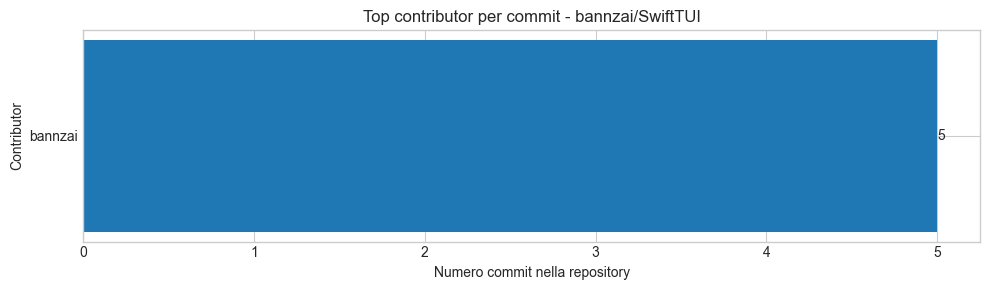

### Top commit relativi ai context file (per numero di context file toccati)

,hash,author,date,context_files,additions,deletions,changes,message,url
0,e14c1390540c22940b3850973eaa8a19b93c12eb,bannzai,2025-07-04T12:05:46Z,1,218,54,272,Fix CLAUDE.md,https://github.com/bannzai/SwiftTUI/compare/54d7543951908a3f4ce642b1dd8948cf127aa7fc...e14c1390540c22940b3850973eaa8a19b93c12eb
1,5da135c6e17a65e8679bca1ad8fa362767a1f124,bannzai,2025-07-04T12:07:44Z,1,89,89,178,Tranlsate to ja,https://github.com/bannzai/SwiftTUI/compare/e14c1390540c22940b3850973eaa8a19b93c12eb...5da135c6e17a65e8679bca1ad8fa362767a1f124
2,53f36af9260f0432ae8a7952b96c74916ed95ea7,bannzai,2025-07-13T01:30:10Z,1,2,99,101,docs: CLAUDE.mdのユニットテスト完了状況を更新,https://github.com/bannzai/SwiftTUI/compare/fc3c7648d1c076bb4581484733e2b2dda6f66f72...53f36af9260f0432ae8a7952b96c74916ed95ea7
3,167d1b8ef9833c5da072fdd1cecfe4ab55d0ea20,bannzai,2025-07-12T09:38:50Z,1,99,0,99,Merge branch 'main' into add/test/text,https://github.com/bannzai/SwiftTUI/compare/ec6f73f2d94829ff36d3edecd94b7080fc3916b7...167d1b8ef9833c5da072fdd1cecfe4ab55d0ea20
4,03ce52a6ffb9a129250825afd054d260a440fa78,bannzai,2025-07-11T11:42:06Z,1,98,0,98,Add test case,https://github.com/bannzai/SwiftTUI/compare/12369d100c0a42a109cd9b0c931164480a9d8c18...03ce52a6ffb9a129250825afd054d260a440fa78
5,ec6f73f2d94829ff36d3edecd94b7080fc3916b7,bannzai,2025-07-11T23:21:15Z,1,88,0,88,docs: TextFieldTestsの実装完了をドキュメントに反映,https://github.com/bannzai/SwiftTUI/compare/e1480004239486dde892a48ccd382391d4a97f97...ec6f73f2d94829ff36d3edecd94b7080fc3916b7
6,f8568a1294081310034c5ed1e9f6162f8988eb5d,bannzai,2025-07-14T22:45:08Z,1,80,0,80,docs: READMEとCLAUDE.mdを更新,https://github.com/bannzai/SwiftTUI/compare/2fe87f8aede61bb62fb29a0085207d5228af7e80...f8568a1294081310034c5ed1e9f6162f8988eb5d
7,85959481cc96138269a566566720f6f3ba4da1c8,bannzai,2025-07-09T05:14:59Z,1,66,6,72,feat: フェーズ5 - 高度な状態管理の実装,https://github.com/bannzai/SwiftTUI/compare/b32a31f5d7a108ed6697140a5ec4ef822bd40ffd...85959481cc96138269a566566720f6f3ba4da1c8
8,13a0f7b1bf5cb4a74790db2c2045615989a9d5fa,bannzai,2025-07-05T09:55:15Z,1,42,17,59,Updated CLAUDE.md,https://github.com/bannzai/SwiftTUI/compare/5da135c6e17a65e8679bca1ad8fa362767a1f124...13a0f7b1bf5cb4a74790db2c2045615989a9d5fa
9,9172aa64fa674f90f0e9c231c3da29b6e176f139,bannzai,2025-07-09T16:56:47Z,1,0,55,55,Remove unnecessary section,https://github.com/bannzai/SwiftTUI/compare/5e6c4f0404f5f12cf9b32e6fb825779349c978e1...9172aa64fa674f90f0e9c231c3da29b6e176f139


### Commit context-file con maggiori modifiche (additions + deletions)

,hash,author,date,changes,additions,deletions,context_files,message,url
0,e14c1390540c22940b3850973eaa8a19b93c12eb,bannzai,2025-07-04T12:05:46Z,272,218,54,1,Fix CLAUDE.md,https://github.com/bannzai/SwiftTUI/compare/54d7543951908a3f4ce642b1dd8948cf127aa7fc...e14c1390540c22940b3850973eaa8a19b93c12eb
1,5da135c6e17a65e8679bca1ad8fa362767a1f124,bannzai,2025-07-04T12:07:44Z,178,89,89,1,Tranlsate to ja,https://github.com/bannzai/SwiftTUI/compare/e14c1390540c22940b3850973eaa8a19b93c12eb...5da135c6e17a65e8679bca1ad8fa362767a1f124
2,53f36af9260f0432ae8a7952b96c74916ed95ea7,bannzai,2025-07-13T01:30:10Z,101,2,99,1,docs: CLAUDE.mdのユニットテスト完了状況を更新,https://github.com/bannzai/SwiftTUI/compare/fc3c7648d1c076bb4581484733e2b2dda6f66f72...53f36af9260f0432ae8a7952b96c74916ed95ea7
3,167d1b8ef9833c5da072fdd1cecfe4ab55d0ea20,bannzai,2025-07-12T09:38:50Z,99,99,0,1,Merge branch 'main' into add/test/text,https://github.com/bannzai/SwiftTUI/compare/ec6f73f2d94829ff36d3edecd94b7080fc3916b7...167d1b8ef9833c5da072fdd1cecfe4ab55d0ea20
4,03ce52a6ffb9a129250825afd054d260a440fa78,bannzai,2025-07-11T11:42:06Z,98,98,0,1,Add test case,https://github.com/bannzai/SwiftTUI/compare/12369d100c0a42a109cd9b0c931164480a9d8c18...03ce52a6ffb9a129250825afd054d260a440fa78
5,ec6f73f2d94829ff36d3edecd94b7080fc3916b7,bannzai,2025-07-11T23:21:15Z,88,88,0,1,docs: TextFieldTestsの実装完了をドキュメントに反映,https://github.com/bannzai/SwiftTUI/compare/e1480004239486dde892a48ccd382391d4a97f97...ec6f73f2d94829ff36d3edecd94b7080fc3916b7
6,f8568a1294081310034c5ed1e9f6162f8988eb5d,bannzai,2025-07-14T22:45:08Z,80,80,0,1,docs: READMEとCLAUDE.mdを更新,https://github.com/bannzai/SwiftTUI/compare/2fe87f8aede61bb62fb29a0085207d5228af7e80...f8568a1294081310034c5ed1e9f6162f8988eb5d
7,85959481cc96138269a566566720f6f3ba4da1c8,bannzai,2025-07-09T05:14:59Z,72,66,6,1,feat: フェーズ5 - 高度な状態管理の実装,https://github.com/bannzai/SwiftTUI/compare/b32a31f5d7a108ed6697140a5ec4ef822bd40ffd...85959481cc96138269a566566720f6f3ba4da1c8
8,13a0f7b1bf5cb4a74790db2c2045615989a9d5fa,bannzai,2025-07-05T09:55:15Z,59,42,17,1,Updated CLAUDE.md,https://github.com/bannzai/SwiftTUI/compare/5da135c6e17a65e8679bca1ad8fa362767a1f124...13a0f7b1bf5cb4a74790db2c2045615989a9d5fa
9,9172aa64fa674f90f0e9c231c3da29b6e176f139,bannzai,2025-07-09T16:56:47Z,55,0,55,1,Remove unnecessary section,https://github.com/bannzai/SwiftTUI/compare/5e6c4f0404f5f12cf9b32e6fb825779349c978e1...9172aa64fa674f90f0e9c231c3da29b6e176f139


In [29]:
show_repo_report("bannzai/SwiftTUI")

In [30]:
show_repo_report("czlonkowski/n8n-mcp")

## czlonkowski/n8n-mcp

### Contributor nella repository

Nessun contributor trovato.

### Top commit relativi ai context file (per numero di context file toccati)

,hash,author,date,context_files,additions,deletions,changes,message,url
0,6f11d339ca35a0c3d8b219b585c7488b009aa3fa,czlonkowski,2025-07-07T07:34:31Z,1,800,10,810,restore CLAUDE.md,https://github.com/czlonkowski/n8n-mcp/compare/1f12c4b690d0e320b5a1dbcf43ff0539c3bfed4b...6f11d339ca35a0c3d8b219b585c7488b009aa3fa
1,1f12c4b690d0e320b5a1dbcf43ff0539c3bfed4b,czlonkowski,2025-07-06T20:40:58Z,1,10,661,671,feat: add npx support for zero-installation usage (closes #15),https://github.com/czlonkowski/n8n-mcp/compare/657d8c60889ace9428d527676a7bfb40f72dd78b...1f12c4b690d0e320b5a1dbcf43ff0539c3bfed4b
2,a1992f996466706f6599570d172f07e600673ed7,czlonkowski,2025-07-18T12:01:11Z,1,4,632,636,feat: add version info to health check and fix healthz endpoint,https://github.com/czlonkowski/n8n-mcp/compare/4e80c82e24ca84ab2af26f0369bf68a3a2f0ea0f...a1992f996466706f6599570d172f07e600673ed7
3,8bf670c31ef2efceef48e33e5cf63a313cefe3c2,czlonkowski,2025-06-12T12:18:19Z,1,162,128,290,feat: Implement n8n-MCP Enhancement Plan v2.1 Final,https://github.com/czlonkowski/n8n-mcp/compare/0cff8fbe6a6db0039bf993fa20e69d9789390f93...8bf670c31ef2efceef48e33e5cf63a313cefe3c2
4,0cff8fbe6a6db0039bf993fa20e69d9789390f93,czlonkowski,2025-06-07T16:05:31Z,1,131,17,148,Update documentation with AI Agent extraction features,https://github.com/czlonkowski/n8n-mcp/compare/b51591a87d071e93d1fdb547072fdaa16a7d503c...0cff8fbe6a6db0039bf993fa20e69d9789390f93
5,6d614267afed8d06530bcd510961eb0b8d054535,czlonkowski,2025-07-30T07:42:17Z,1,115,1,116,docs: update testing documentation to reflect actual implementation,https://github.com/czlonkowski/n8n-mcp/compare/48219fb860a77a9b276091a6dac548ae58f9f3e1...6d614267afed8d06530bcd510961eb0b8d054535
6,4e80c82e24ca84ab2af26f0369bf68a3a2f0ea0f,czlonkowski,2025-07-09T18:40:43Z,1,0,112,112,clean Claude.md,https://github.com/czlonkowski/n8n-mcp/compare/87f0cfc4dc5805f8a2858596fae629a31615ca8d...4e80c82e24ca84ab2af26f0369bf68a3a2f0ea0f
7,66f5d74e4286941525e2347dd979a6b0a88d53af,czlonkowski,2025-06-12T16:45:20Z,1,57,47,104,feat: implement node parser and property extractor with versioned node support,https://github.com/czlonkowski/n8n-mcp/compare/8bf670c31ef2efceef48e33e5cf63a313cefe3c2...66f5d74e4286941525e2347dd979a6b0a88d53af
8,1907e5ce8e10a1cb4b6986c4b9bd787197261b39,czlonkowski,2025-06-29T17:06:31Z,1,8,88,96,refactor: major cleanup of legacy and temporary files,https://github.com/czlonkowski/n8n-mcp/compare/0aab176e7d9b701c92818897c6c8afc65d03d29c...1907e5ce8e10a1cb4b6986c4b9bd787197261b39
9,c95313f3437762841c21ee4f0514abdebab8cbc4,czlonkowski,2025-06-18T21:09:18Z,1,60,12,72,feat: optimize Docker build to exclude n8n dependencies,https://github.com/czlonkowski/n8n-mcp/compare/22dc0bdc4b1651bd0a797e80e6d4cc877a03e99f...c95313f3437762841c21ee4f0514abdebab8cbc4


### Commit context-file con maggiori modifiche (additions + deletions)

,hash,author,date,changes,additions,deletions,context_files,message,url
0,6f11d339ca35a0c3d8b219b585c7488b009aa3fa,czlonkowski,2025-07-07T07:34:31Z,810,800,10,1,restore CLAUDE.md,https://github.com/czlonkowski/n8n-mcp/compare/1f12c4b690d0e320b5a1dbcf43ff0539c3bfed4b...6f11d339ca35a0c3d8b219b585c7488b009aa3fa
1,1f12c4b690d0e320b5a1dbcf43ff0539c3bfed4b,czlonkowski,2025-07-06T20:40:58Z,671,10,661,1,feat: add npx support for zero-installation usage (closes #15),https://github.com/czlonkowski/n8n-mcp/compare/657d8c60889ace9428d527676a7bfb40f72dd78b...1f12c4b690d0e320b5a1dbcf43ff0539c3bfed4b
2,a1992f996466706f6599570d172f07e600673ed7,czlonkowski,2025-07-18T12:01:11Z,636,4,632,1,feat: add version info to health check and fix healthz endpoint,https://github.com/czlonkowski/n8n-mcp/compare/4e80c82e24ca84ab2af26f0369bf68a3a2f0ea0f...a1992f996466706f6599570d172f07e600673ed7
3,8bf670c31ef2efceef48e33e5cf63a313cefe3c2,czlonkowski,2025-06-12T12:18:19Z,290,162,128,1,feat: Implement n8n-MCP Enhancement Plan v2.1 Final,https://github.com/czlonkowski/n8n-mcp/compare/0cff8fbe6a6db0039bf993fa20e69d9789390f93...8bf670c31ef2efceef48e33e5cf63a313cefe3c2
4,0cff8fbe6a6db0039bf993fa20e69d9789390f93,czlonkowski,2025-06-07T16:05:31Z,148,131,17,1,Update documentation with AI Agent extraction features,https://github.com/czlonkowski/n8n-mcp/compare/b51591a87d071e93d1fdb547072fdaa16a7d503c...0cff8fbe6a6db0039bf993fa20e69d9789390f93
5,6d614267afed8d06530bcd510961eb0b8d054535,czlonkowski,2025-07-30T07:42:17Z,116,115,1,1,docs: update testing documentation to reflect actual implementation,https://github.com/czlonkowski/n8n-mcp/compare/48219fb860a77a9b276091a6dac548ae58f9f3e1...6d614267afed8d06530bcd510961eb0b8d054535
6,4e80c82e24ca84ab2af26f0369bf68a3a2f0ea0f,czlonkowski,2025-07-09T18:40:43Z,112,0,112,1,clean Claude.md,https://github.com/czlonkowski/n8n-mcp/compare/87f0cfc4dc5805f8a2858596fae629a31615ca8d...4e80c82e24ca84ab2af26f0369bf68a3a2f0ea0f
7,66f5d74e4286941525e2347dd979a6b0a88d53af,czlonkowski,2025-06-12T16:45:20Z,104,57,47,1,feat: implement node parser and property extractor with versioned node support,https://github.com/czlonkowski/n8n-mcp/compare/8bf670c31ef2efceef48e33e5cf63a313cefe3c2...66f5d74e4286941525e2347dd979a6b0a88d53af
8,1907e5ce8e10a1cb4b6986c4b9bd787197261b39,czlonkowski,2025-06-29T17:06:31Z,96,8,88,1,refactor: major cleanup of legacy and temporary files,https://github.com/czlonkowski/n8n-mcp/compare/0aab176e7d9b701c92818897c6c8afc65d03d29c...1907e5ce8e10a1cb4b6986c4b9bd787197261b39
9,c95313f3437762841c21ee4f0514abdebab8cbc4,czlonkowski,2025-06-18T21:09:18Z,72,60,12,1,feat: optimize Docker build to exclude n8n dependencies,https://github.com/czlonkowski/n8n-mcp/compare/22dc0bdc4b1651bd0a797e80e6d4cc877a03e99f...c95313f3437762841c21ee4f0514abdebab8cbc4


In [31]:
show_repo_report("devill/refakts")

## devill/refakts

### Contributor nella repository

Nessun contributor trovato.

### Top commit relativi ai context file (per numero di context file toccati)

,hash,author,date,context_files,additions,deletions,changes,message,url
0,a1782a00563c840f68e983c7b67841ff2d48a5e4,Ivett Ördög,2025-07-26T15:19:32Z,1,80,304,384,Restructure CLAUDE.md and create specialized documentation guides,https://github.com/devill/refakts/compare/a7a54c1ae877cb854dfea77f970ca7fea7a20a61...a1782a00563c840f68e983c7b67841ff2d48a5e4
1,3520759bd48f94b182516fe17d2e3ad463c6c539,Piotr Jurczynski,2025-07-21T15:17:05Z,1,175,42,217,Merge remote-tracking branch 'upstream/main' into feat/sort-methods,https://github.com/devill/refakts/compare/b029e9e01e1fe43bd3108fd938f367547852f4d9...3520759bd48f94b182516fe17d2e3ad463c6c539
2,4d5d21e981ac0437425859a04e3a42e589773d67,Ivett Ördög,2025-07-04T11:46:29Z,1,32,112,144,Integrate roadmap into CLAUDE.md and clean up documentation,https://github.com/devill/refakts/compare/17922857dfbe42253fa39857c5671d8352f32778...4d5d21e981ac0437425859a04e3a42e589773d67
3,0c4af3c5be747de83651c841d7a50c640885f4d4,Ivett Ördög,2025-07-04T11:54:02Z,1,15,55,70,Resolve quality issues and improve documentation structure,https://github.com/devill/refakts/compare/4d5d21e981ac0437425859a04e3a42e589773d67...0c4af3c5be747de83651c841d7a50c640885f4d4
4,b6be74b1a6c1b85eedd3d3d55a3148042b15c0fa,Ivett Ördög,2025-07-02T20:30:21Z,1,38,25,63,Fix node-finding testing architecture,https://github.com/devill/refakts/compare/884a2f14fd659fd63be32df9a16a04c34530d364...b6be74b1a6c1b85eedd3d3d55a3148042b15c0fa
5,f599eadf069cf1448be435d586b8ac842eb04f16,Ivett Ördög,2025-07-02T18:19:52Z,1,61,0,61,Add AI-driven feature roadmap system,https://github.com/devill/refakts/compare/b081343f6c47fec0882151166a944beb3b85b86a...f599eadf069cf1448be435d586b8ac842eb04f16
6,3cfec8b216cf5ccffc2d9ade691f99d1cfcd106f,Ivett Ördög,2025-07-11T19:46:19Z,1,38,20,58,Hide incomplete commands from help and add --show-incomplete flag,https://github.com/devill/refakts/compare/900f001d2d7e9379672bee3ac99e2344f6838aaf...3cfec8b216cf5ccffc2d9ade691f99d1cfcd106f
7,5be8bc688e6d7be2c5714d7cd883eb1076f90cb8,Ivett Ördög,2025-06-30T09:12:57Z,1,50,7,57,CLAUDE.md cleanup.,https://github.com/devill/refakts/compare/e74a6e3adcbf0f795b1a784f5f6f00c1034cca7b...5be8bc688e6d7be2c5714d7cd883eb1076f90cb8
8,30dc72fc3008060300b04dfc503d699f2144ebb5,Ivett Ördög,2025-06-28T22:11:13Z,1,38,10,48,Add comprehensive refactoring completion tracking system,https://github.com/devill/refakts/compare/dd541362c4f5c9936a6106bab8275a76355d6a00...30dc72fc3008060300b04dfc503d699f2144ebb5
9,53543407153fe1a970fd085801b85baecaba8d5e,Ivett Ördög,2025-07-16T22:53:35Z,1,45,0,45,Document output handler architecture pattern for new commands,https://github.com/devill/refakts/compare/48559eac79e986aa10bd04a3f0d66e6a54078115...53543407153fe1a970fd085801b85baecaba8d5e


### Commit context-file con maggiori modifiche (additions + deletions)

,hash,author,date,changes,additions,deletions,context_files,message,url
0,a1782a00563c840f68e983c7b67841ff2d48a5e4,Ivett Ördög,2025-07-26T15:19:32Z,384,80,304,1,Restructure CLAUDE.md and create specialized documentation guides,https://github.com/devill/refakts/compare/a7a54c1ae877cb854dfea77f970ca7fea7a20a61...a1782a00563c840f68e983c7b67841ff2d48a5e4
1,3520759bd48f94b182516fe17d2e3ad463c6c539,Piotr Jurczynski,2025-07-21T15:17:05Z,217,175,42,1,Merge remote-tracking branch 'upstream/main' into feat/sort-methods,https://github.com/devill/refakts/compare/b029e9e01e1fe43bd3108fd938f367547852f4d9...3520759bd48f94b182516fe17d2e3ad463c6c539
2,4d5d21e981ac0437425859a04e3a42e589773d67,Ivett Ördög,2025-07-04T11:46:29Z,144,32,112,1,Integrate roadmap into CLAUDE.md and clean up documentation,https://github.com/devill/refakts/compare/17922857dfbe42253fa39857c5671d8352f32778...4d5d21e981ac0437425859a04e3a42e589773d67
3,0c4af3c5be747de83651c841d7a50c640885f4d4,Ivett Ördög,2025-07-04T11:54:02Z,70,15,55,1,Resolve quality issues and improve documentation structure,https://github.com/devill/refakts/compare/4d5d21e981ac0437425859a04e3a42e589773d67...0c4af3c5be747de83651c841d7a50c640885f4d4
4,b6be74b1a6c1b85eedd3d3d55a3148042b15c0fa,Ivett Ördög,2025-07-02T20:30:21Z,63,38,25,1,Fix node-finding testing architecture,https://github.com/devill/refakts/compare/884a2f14fd659fd63be32df9a16a04c34530d364...b6be74b1a6c1b85eedd3d3d55a3148042b15c0fa
5,f599eadf069cf1448be435d586b8ac842eb04f16,Ivett Ördög,2025-07-02T18:19:52Z,61,61,0,1,Add AI-driven feature roadmap system,https://github.com/devill/refakts/compare/b081343f6c47fec0882151166a944beb3b85b86a...f599eadf069cf1448be435d586b8ac842eb04f16
6,3cfec8b216cf5ccffc2d9ade691f99d1cfcd106f,Ivett Ördög,2025-07-11T19:46:19Z,58,38,20,1,Hide incomplete commands from help and add --show-incomplete flag,https://github.com/devill/refakts/compare/900f001d2d7e9379672bee3ac99e2344f6838aaf...3cfec8b216cf5ccffc2d9ade691f99d1cfcd106f
7,5be8bc688e6d7be2c5714d7cd883eb1076f90cb8,Ivett Ördög,2025-06-30T09:12:57Z,57,50,7,1,CLAUDE.md cleanup.,https://github.com/devill/refakts/compare/e74a6e3adcbf0f795b1a784f5f6f00c1034cca7b...5be8bc688e6d7be2c5714d7cd883eb1076f90cb8
8,30dc72fc3008060300b04dfc503d699f2144ebb5,Ivett Ördög,2025-06-28T22:11:13Z,48,38,10,1,Add comprehensive refactoring completion tracking system,https://github.com/devill/refakts/compare/dd541362c4f5c9936a6106bab8275a76355d6a00...30dc72fc3008060300b04dfc503d699f2144ebb5
9,53543407153fe1a970fd085801b85baecaba8d5e,Ivett Ördög,2025-07-16T22:53:35Z,45,45,0,1,Document output handler architecture pattern for new commands,https://github.com/devill/refakts/compare/48559eac79e986aa10bd04a3f0d66e6a54078115...53543407153fe1a970fd085801b85baecaba8d5e


In [32]:
show_repo_report("docdyhr/mcp-wordpress")

## docdyhr/mcp-wordpress

### Contributor nella repository

Nessun contributor trovato.

### Top commit relativi ai context file (per numero di context file toccati)

,hash,author,date,context_files,additions,deletions,changes,message,url
0,8105023b5d04621466bcd9d150a3c45a256d5045,Thomas Juul Dyhr,2025-09-04T11:21:58Z,1,61,1738,1799,feat(architecture): Complete test suite architectural improvements and fixes,https://github.com/docdyhr/mcp-wordpress/compare/12d03fde4984e3609558c2ef29f82f5c6eea8765...8105023b5d04621466bcd9d150a3c45a256d5045
1,1f2bf2b36e1ee6d006667cf8b6454375452ff1a6,Thomas Juul Dyhr,2025-07-19T23:37:07Z,1,204,977,1181,docs: compact CLAUDE.md for enhanced usability,https://github.com/docdyhr/mcp-wordpress/compare/dbabdf24be16cc608094ca5f9d13a67a25af1984...1f2bf2b36e1ee6d006667cf8b6454375452ff1a6
2,90a7ea38699363aa001950dcfc42689a3d139650,Thomas Juul Dyhr,2025-08-28T04:05:54Z,1,808,0,808,feat: release v2.7.0 with composition architecture and complete SEO toolkit,https://github.com/docdyhr/mcp-wordpress/compare/af468690b6578aed6daed7cdd46206df00951684...90a7ea38699363aa001950dcfc42689a3d139650
3,dbabdf24be16cc608094ca5f9d13a67a25af1984,Thomas Juul Dyhr,2025-07-19T13:21:03Z,1,417,0,417,docs: comprehensive documentation enhancement and JSDoc improvements,https://github.com/docdyhr/mcp-wordpress/compare/9aedfabd0995656f78b3e8606f8a25329334de37...dbabdf24be16cc608094ca5f9d13a67a25af1984
4,1b9358616492f36d4a7629c02ad897c6038ddb33,Thomas Juul Dyhr,2025-08-11T13:35:53Z,1,325,7,332,"release: Production Readiness v2.5.0 - Enhanced Testing, Security & Monitoring (#71)",https://github.com/docdyhr/mcp-wordpress/compare/8fb0d3be67e8e87afbd0074e7a257ccf30f607a3...1b9358616492f36d4a7629c02ad897c6038ddb33
5,49c3d73f29836703d20b39eccbd7e43c82c3f21f,Thomas Juul Dyhr,2025-06-26T23:05:41Z,1,106,159,265,feat: implement multi-site support,https://github.com/docdyhr/mcp-wordpress/compare/a0ec182fb658b8dbec970ff72754f638505f375c...49c3d73f29836703d20b39eccbd7e43c82c3f21f
6,af468690b6578aed6daed7cdd46206df00951684,Thomas Juul Dyhr,2025-08-22T19:02:19Z,1,120,0,120,fix: update security contact information to remove invalid email link,https://github.com/docdyhr/mcp-wordpress/compare/c25087e1e604d325347c5c02e588543385e2eb87...af468690b6578aed6daed7cdd46206df00951684
7,8fb0d3be67e8e87afbd0074e7a257ccf30f607a3,Thomas Juul Dyhr,2025-08-08T17:08:53Z,1,110,0,110,ci: enhance CI/CD pipeline with performance optimizations and reliability improvements (#52),https://github.com/docdyhr/mcp-wordpress/compare/8e43b0050b46ce9900ac4e706489d8f05667798f...8fb0d3be67e8e87afbd0074e7a257ccf30f607a3
8,001162c086d77c5f385b0908f87e904235412000,Thomas Juul Dyhr,2025-07-03T02:18:57Z,1,95,0,95,feat: implement Claude Code hooks and Desktop Extension (DXT) support,https://github.com/docdyhr/mcp-wordpress/compare/90c34a231faaa704adfd9763986aeec220eb38e1...001162c086d77c5f385b0908f87e904235412000
9,25878af1fd0563654b990801ce68490433dd49a9,Thomas Juul Dyhr,2025-06-27T17:39:33Z,1,73,19,92,security: address security review issues and improve documentation,https://github.com/docdyhr/mcp-wordpress/compare/49c3d73f29836703d20b39eccbd7e43c82c3f21f...25878af1fd0563654b990801ce68490433dd49a9


### Commit context-file con maggiori modifiche (additions + deletions)

,hash,author,date,changes,additions,deletions,context_files,message,url
0,8105023b5d04621466bcd9d150a3c45a256d5045,Thomas Juul Dyhr,2025-09-04T11:21:58Z,1799,61,1738,1,feat(architecture): Complete test suite architectural improvements and fixes,https://github.com/docdyhr/mcp-wordpress/compare/12d03fde4984e3609558c2ef29f82f5c6eea8765...8105023b5d04621466bcd9d150a3c45a256d5045
1,1f2bf2b36e1ee6d006667cf8b6454375452ff1a6,Thomas Juul Dyhr,2025-07-19T23:37:07Z,1181,204,977,1,docs: compact CLAUDE.md for enhanced usability,https://github.com/docdyhr/mcp-wordpress/compare/dbabdf24be16cc608094ca5f9d13a67a25af1984...1f2bf2b36e1ee6d006667cf8b6454375452ff1a6
2,90a7ea38699363aa001950dcfc42689a3d139650,Thomas Juul Dyhr,2025-08-28T04:05:54Z,808,808,0,1,feat: release v2.7.0 with composition architecture and complete SEO toolkit,https://github.com/docdyhr/mcp-wordpress/compare/af468690b6578aed6daed7cdd46206df00951684...90a7ea38699363aa001950dcfc42689a3d139650
3,dbabdf24be16cc608094ca5f9d13a67a25af1984,Thomas Juul Dyhr,2025-07-19T13:21:03Z,417,417,0,1,docs: comprehensive documentation enhancement and JSDoc improvements,https://github.com/docdyhr/mcp-wordpress/compare/9aedfabd0995656f78b3e8606f8a25329334de37...dbabdf24be16cc608094ca5f9d13a67a25af1984
4,1b9358616492f36d4a7629c02ad897c6038ddb33,Thomas Juul Dyhr,2025-08-11T13:35:53Z,332,325,7,1,"release: Production Readiness v2.5.0 - Enhanced Testing, Security & Monitoring (#71)",https://github.com/docdyhr/mcp-wordpress/compare/8fb0d3be67e8e87afbd0074e7a257ccf30f607a3...1b9358616492f36d4a7629c02ad897c6038ddb33
5,49c3d73f29836703d20b39eccbd7e43c82c3f21f,Thomas Juul Dyhr,2025-06-26T23:05:41Z,265,106,159,1,feat: implement multi-site support,https://github.com/docdyhr/mcp-wordpress/compare/a0ec182fb658b8dbec970ff72754f638505f375c...49c3d73f29836703d20b39eccbd7e43c82c3f21f
6,af468690b6578aed6daed7cdd46206df00951684,Thomas Juul Dyhr,2025-08-22T19:02:19Z,120,120,0,1,fix: update security contact information to remove invalid email link,https://github.com/docdyhr/mcp-wordpress/compare/c25087e1e604d325347c5c02e588543385e2eb87...af468690b6578aed6daed7cdd46206df00951684
7,8fb0d3be67e8e87afbd0074e7a257ccf30f607a3,Thomas Juul Dyhr,2025-08-08T17:08:53Z,110,110,0,1,ci: enhance CI/CD pipeline with performance optimizations and reliability improvements (#52),https://github.com/docdyhr/mcp-wordpress/compare/8e43b0050b46ce9900ac4e706489d8f05667798f...8fb0d3be67e8e87afbd0074e7a257ccf30f607a3
8,001162c086d77c5f385b0908f87e904235412000,Thomas Juul Dyhr,2025-07-03T02:18:57Z,95,95,0,1,feat: implement Claude Code hooks and Desktop Extension (DXT) support,https://github.com/docdyhr/mcp-wordpress/compare/90c34a231faaa704adfd9763986aeec220eb38e1...001162c086d77c5f385b0908f87e904235412000
9,25878af1fd0563654b990801ce68490433dd49a9,Thomas Juul Dyhr,2025-06-27T17:39:33Z,92,73,19,1,security: address security review issues and improve documentation,https://github.com/docdyhr/mcp-wordpress/compare/49c3d73f29836703d20b39eccbd7e43c82c3f21f...25878af1fd0563654b990801ce68490433dd49a9


In [33]:
show_repo_report("evmts/guillotine")

## evmts/guillotine

### Contributor nella repository

Nessun contributor trovato.

### Top commit relativi ai context file (per numero di context file toccati)

,hash,author,date,context_files,additions,deletions,changes,message,url
0,eb6345f69d4ca565f7381cd111deee03479511aa,William Cory,2025-08-25T03:23:33Z,1,87,995,1082,📚docs: consolidate agent guidelines into CLAUDE.md; symlink AGENTS.md\n\n🤖 Generated with [Claude Code](https://claude.ai/code)\n\nCo-Authored-By: Claude <noreply@anthropic.com>,https://github.com/evmts/guillotine/compare/567600efc8e933cc78bb619573298a70c3bf6f18...eb6345f69d4ca565f7381cd111deee03479511aa
1,6be5b8cef0e6506501fc00939b539f3f347f4c7f,William Cory,2025-09-14T08:21:09Z,1,97,419,516,📚 docs: Optimize CLAUDE.md files for token efficiency,https://github.com/evmts/guillotine/compare/c6ec0bc33172422fd5757c8e680d8a42fa25c504...6be5b8cef0e6506501fc00939b539f3f347f4c7f
2,bc3074349f00581dcf47c1a11a67f1b5582fdd73,William Cory,2025-07-11T11:03:14Z,1,275,131,406,📚 docs: enhance CLAUDE.md with comprehensive project documentation,https://github.com/evmts/guillotine/compare/1373872fdc108be7a874ac7bdb8997d9bca8a47f...bc3074349f00581dcf47c1a11a67f1b5582fdd73
3,59966f9920e6ea882f43e93c38a5c9bdbb6b1b11,William Cory,2025-09-12T23:38:04Z,1,319,0,319,docs: Add cli --help to CLAUDE.md,https://github.com/evmts/guillotine/compare/057cbd3a562383ba40f1f8df6639a4299852fc24...59966f9920e6ea882f43e93c38a5c9bdbb6b1b11
4,13764c9f2acdd5210d6c3ed3389aa2af98807b86,William Cory,2025-08-24T18:12:18Z,1,141,172,313,📚 docs: update architecture documentation for new EVM implementation,https://github.com/evmts/guillotine/compare/330c9f96d84e871d499dda4ea76528893e80fa6e...13764c9f2acdd5210d6c3ed3389aa2af98807b86
5,b8c1207d2d5358f628087ee30c62c3940fc27f56,William Cory,2025-08-24T00:01:42Z,1,180,0,180,📚 docs: add EVM architecture and coding guidelines to CLAUDE.md,https://github.com/evmts/guillotine/compare/9d33d0b0fee03455a1611a2b788ad93c9e150eef...b8c1207d2d5358f628087ee30c62c3940fc27f56
6,9eaf5a828324c105c586c89207000f74ffa27e43,William Cory,2025-07-18T20:51:48Z,1,108,30,138,🔧 refactor: eliminate Memory API footgun with safer shared buffer design,https://github.com/evmts/guillotine/compare/b6d06c3951703272a423e489638bde38e8c47a5f...9eaf5a828324c105c586c89207000f74ffa27e43
7,330c9f96d84e871d499dda4ea76528893e80fa6e,William Cory,2025-08-24T00:10:03Z,1,127,0,127,📚 docs: add advanced EVM architectural patterns to CLAUDE.md,https://github.com/evmts/guillotine/compare/b8c1207d2d5358f628087ee30c62c3940fc27f56...330c9f96d84e871d499dda4ea76528893e80fa6e
8,855e72f7b93a2ebfee6370bb59af34cf89df012c,William Cory,2025-09-14T20:05:38Z,1,72,17,89,📚 docs: Update CLAUDE.md files and architecture documentation,https://github.com/evmts/guillotine/compare/dca3cce67c8da2be41e9b6c61d9a8d7a1c997743...855e72f7b93a2ebfee6370bb59af34cf89df012c
9,b475375a4ae0b7c0ab5011e1dcc6438b2f9d567c,William Cory,2025-09-07T17:22:51Z,1,35,33,68,chore: Small claude cleanup,https://github.com/evmts/guillotine/compare/bcc1d9e4c9f4675cc7945a177ef613f17e59b137...b475375a4ae0b7c0ab5011e1dcc6438b2f9d567c


### Commit context-file con maggiori modifiche (additions + deletions)

,hash,author,date,changes,additions,deletions,context_files,message,url
0,eb6345f69d4ca565f7381cd111deee03479511aa,William Cory,2025-08-25T03:23:33Z,1082,87,995,1,📚docs: consolidate agent guidelines into CLAUDE.md; symlink AGENTS.md\n\n🤖 Generated with [Claude Code](https://claude.ai/code)\n\nCo-Authored-By: Claude <noreply@anthropic.com>,https://github.com/evmts/guillotine/compare/567600efc8e933cc78bb619573298a70c3bf6f18...eb6345f69d4ca565f7381cd111deee03479511aa
1,6be5b8cef0e6506501fc00939b539f3f347f4c7f,William Cory,2025-09-14T08:21:09Z,516,97,419,1,📚 docs: Optimize CLAUDE.md files for token efficiency,https://github.com/evmts/guillotine/compare/c6ec0bc33172422fd5757c8e680d8a42fa25c504...6be5b8cef0e6506501fc00939b539f3f347f4c7f
2,bc3074349f00581dcf47c1a11a67f1b5582fdd73,William Cory,2025-07-11T11:03:14Z,406,275,131,1,📚 docs: enhance CLAUDE.md with comprehensive project documentation,https://github.com/evmts/guillotine/compare/1373872fdc108be7a874ac7bdb8997d9bca8a47f...bc3074349f00581dcf47c1a11a67f1b5582fdd73
3,59966f9920e6ea882f43e93c38a5c9bdbb6b1b11,William Cory,2025-09-12T23:38:04Z,319,319,0,1,docs: Add cli --help to CLAUDE.md,https://github.com/evmts/guillotine/compare/057cbd3a562383ba40f1f8df6639a4299852fc24...59966f9920e6ea882f43e93c38a5c9bdbb6b1b11
4,13764c9f2acdd5210d6c3ed3389aa2af98807b86,William Cory,2025-08-24T18:12:18Z,313,141,172,1,📚 docs: update architecture documentation for new EVM implementation,https://github.com/evmts/guillotine/compare/330c9f96d84e871d499dda4ea76528893e80fa6e...13764c9f2acdd5210d6c3ed3389aa2af98807b86
5,b8c1207d2d5358f628087ee30c62c3940fc27f56,William Cory,2025-08-24T00:01:42Z,180,180,0,1,📚 docs: add EVM architecture and coding guidelines to CLAUDE.md,https://github.com/evmts/guillotine/compare/9d33d0b0fee03455a1611a2b788ad93c9e150eef...b8c1207d2d5358f628087ee30c62c3940fc27f56
6,9eaf5a828324c105c586c89207000f74ffa27e43,William Cory,2025-07-18T20:51:48Z,138,108,30,1,🔧 refactor: eliminate Memory API footgun with safer shared buffer design,https://github.com/evmts/guillotine/compare/b6d06c3951703272a423e489638bde38e8c47a5f...9eaf5a828324c105c586c89207000f74ffa27e43
7,330c9f96d84e871d499dda4ea76528893e80fa6e,William Cory,2025-08-24T00:10:03Z,127,127,0,1,📚 docs: add advanced EVM architectural patterns to CLAUDE.md,https://github.com/evmts/guillotine/compare/b8c1207d2d5358f628087ee30c62c3940fc27f56...330c9f96d84e871d499dda4ea76528893e80fa6e
8,855e72f7b93a2ebfee6370bb59af34cf89df012c,William Cory,2025-09-14T20:05:38Z,89,72,17,1,📚 docs: Update CLAUDE.md files and architecture documentation,https://github.com/evmts/guillotine/compare/dca3cce67c8da2be41e9b6c61d9a8d7a1c997743...855e72f7b93a2ebfee6370bb59af34cf89df012c
9,b475375a4ae0b7c0ab5011e1dcc6438b2f9d567c,William Cory,2025-09-07T17:22:51Z,68,35,33,1,chore: Small claude cleanup,https://github.com/evmts/guillotine/compare/bcc1d9e4c9f4675cc7945a177ef613f17e59b137...b475375a4ae0b7c0ab5011e1dcc6438b2f9d567c


In [34]:
show_repo_report("julep-ai/steadytext")

## julep-ai/steadytext

### Contributor nella repository

Nessun contributor trovato.

### Top commit relativi ai context file (per numero di context file toccati)

,hash,author,date,context_files,additions,deletions,changes,message,url
0,6ab81d81515c2c2fb4f01cd28124ed179c5096fb,Diwank Singh Tomer,2025-09-07T14:59:57Z,1,123,487,610,feat: Add comprehensive Prompt Registry feature for PostgreSQL extension (#105),https://github.com/julep-ai/steadytext/compare/b7251ea3400a2f68c02a6beeac7d06c5557971bf...6ab81d81515c2c2fb4f01cd28124ed179c5096fb
1,c48a0e59bd4a2d5d3cecd8e1c94385bdfa6be68f,Diwank Singh Tomer,2025-07-31T13:01:51Z,1,42,420,462,feat: add 'unsafe' mode for remote models with seed support (#73),https://github.com/julep-ai/steadytext/compare/00e7f329597e25a410087d27899234c058913521...c48a0e59bd4a2d5d3cecd8e1c94385bdfa6be68f
2,83f11c4e76d98b89407581324de5d8dddf80176c,Diwank Singh Tomer,2025-06-24T11:37:51Z,1,433,27,460,"v1.3.3 -- daemon mode, faiss index, fixes (#22)",https://github.com/julep-ai/steadytext/compare/80bc35112d1c5514e533af15761e6ac84584a98b...83f11c4e76d98b89407581324de5d8dddf80176c
3,00e7f329597e25a410087d27899234c058913521,Diwank Singh Tomer,2025-07-31T08:20:14Z,1,56,241,297,docs: cleanup CLAUDE.md files and AIDEV-* anchor comments for redundancy (#72),https://github.com/julep-ai/steadytext/compare/e1bf4a69a11b0ffe13ba83a0d42beec2ab3690db...00e7f329597e25a410087d27899234c058913521
4,4e6939b7453d977684c295840026dc076b08b64d,Diwank Singh Tomer,2025-08-27T07:27:08Z,1,139,8,147,fix: fix pg ext & update version to 2025.8.26 (#103),https://github.com/julep-ai/steadytext/compare/e85ff78aa0a17acc5508325f19d961e4632aa962...4e6939b7453d977684c295840026dc076b08b64d
5,52e591d9388488ee64e3713a5625a4ccbacedfb8,Diwank Singh Tomer,2025-11-27T07:26:17Z,1,85,4,89,fix: Simplify pg_steadytext and fix the max character limit (#110),https://github.com/julep-ai/steadytext/compare/128ce60c8fdea1c0522ced4551831bb7aca95381...52e591d9388488ee64e3713a5625a4ccbacedfb8
6,28aeefdeba4ed47914784833e64358af674ce91e,Diwank Singh Tomer,2025-07-05T05:29:54Z,1,55,18,73,fix: Use llama.cpp grammars directly instead of Outlines for structured output (#26),https://github.com/julep-ai/steadytext/compare/e330bef071e98219cf18c723bdff55350cb8ff1b...28aeefdeba4ed47914784833e64358af674ce91e
7,e330bef071e98219cf18c723bdff55350cb8ff1b,Diwank Singh Tomer,2025-07-03T18:27:06Z,1,66,0,66,feat: Structured json support (unfinished),https://github.com/julep-ai/steadytext/compare/a1d3545c360c4245e70734d298264c4a09b3c0bf...e330bef071e98219cf18c723bdff55350cb8ff1b
8,273e17d7d3b179967a4c44267fa4740746833cd6,Diwank Singh Tomer,2025-06-30T18:19:24Z,1,58,0,58,v2.2.0,https://github.com/julep-ai/steadytext/compare/fee3d8a7e1b8ac00ae2b48f64c00bb9a1bb66334...273e17d7d3b179967a4c44267fa4740746833cd6
9,bce7f4e083bc459457a1cd76b9d82678fa544ac2,Diwank Singh Tomer,2025-07-08T09:01:31Z,1,50,0,50,feat: create packages for different Linux distros (#41),https://github.com/julep-ai/steadytext/compare/5544b5bdf6379d7e0ce2d58b05160333e978ce61...bce7f4e083bc459457a1cd76b9d82678fa544ac2


### Commit context-file con maggiori modifiche (additions + deletions)

,hash,author,date,changes,additions,deletions,context_files,message,url
0,6ab81d81515c2c2fb4f01cd28124ed179c5096fb,Diwank Singh Tomer,2025-09-07T14:59:57Z,610,123,487,1,feat: Add comprehensive Prompt Registry feature for PostgreSQL extension (#105),https://github.com/julep-ai/steadytext/compare/b7251ea3400a2f68c02a6beeac7d06c5557971bf...6ab81d81515c2c2fb4f01cd28124ed179c5096fb
1,c48a0e59bd4a2d5d3cecd8e1c94385bdfa6be68f,Diwank Singh Tomer,2025-07-31T13:01:51Z,462,42,420,1,feat: add 'unsafe' mode for remote models with seed support (#73),https://github.com/julep-ai/steadytext/compare/00e7f329597e25a410087d27899234c058913521...c48a0e59bd4a2d5d3cecd8e1c94385bdfa6be68f
2,83f11c4e76d98b89407581324de5d8dddf80176c,Diwank Singh Tomer,2025-06-24T11:37:51Z,460,433,27,1,"v1.3.3 -- daemon mode, faiss index, fixes (#22)",https://github.com/julep-ai/steadytext/compare/80bc35112d1c5514e533af15761e6ac84584a98b...83f11c4e76d98b89407581324de5d8dddf80176c
3,00e7f329597e25a410087d27899234c058913521,Diwank Singh Tomer,2025-07-31T08:20:14Z,297,56,241,1,docs: cleanup CLAUDE.md files and AIDEV-* anchor comments for redundancy (#72),https://github.com/julep-ai/steadytext/compare/e1bf4a69a11b0ffe13ba83a0d42beec2ab3690db...00e7f329597e25a410087d27899234c058913521
4,4e6939b7453d977684c295840026dc076b08b64d,Diwank Singh Tomer,2025-08-27T07:27:08Z,147,139,8,1,fix: fix pg ext & update version to 2025.8.26 (#103),https://github.com/julep-ai/steadytext/compare/e85ff78aa0a17acc5508325f19d961e4632aa962...4e6939b7453d977684c295840026dc076b08b64d
5,52e591d9388488ee64e3713a5625a4ccbacedfb8,Diwank Singh Tomer,2025-11-27T07:26:17Z,89,85,4,1,fix: Simplify pg_steadytext and fix the max character limit (#110),https://github.com/julep-ai/steadytext/compare/128ce60c8fdea1c0522ced4551831bb7aca95381...52e591d9388488ee64e3713a5625a4ccbacedfb8
6,28aeefdeba4ed47914784833e64358af674ce91e,Diwank Singh Tomer,2025-07-05T05:29:54Z,73,55,18,1,fix: Use llama.cpp grammars directly instead of Outlines for structured output (#26),https://github.com/julep-ai/steadytext/compare/e330bef071e98219cf18c723bdff55350cb8ff1b...28aeefdeba4ed47914784833e64358af674ce91e
7,e330bef071e98219cf18c723bdff55350cb8ff1b,Diwank Singh Tomer,2025-07-03T18:27:06Z,66,66,0,1,feat: Structured json support (unfinished),https://github.com/julep-ai/steadytext/compare/a1d3545c360c4245e70734d298264c4a09b3c0bf...e330bef071e98219cf18c723bdff55350cb8ff1b
8,273e17d7d3b179967a4c44267fa4740746833cd6,Diwank Singh Tomer,2025-06-30T18:19:24Z,58,58,0,1,v2.2.0,https://github.com/julep-ai/steadytext/compare/fee3d8a7e1b8ac00ae2b48f64c00bb9a1bb66334...273e17d7d3b179967a4c44267fa4740746833cd6
9,bce7f4e083bc459457a1cd76b9d82678fa544ac2,Diwank Singh Tomer,2025-07-08T09:01:31Z,50,50,0,1,feat: create packages for different Linux distros (#41),https://github.com/julep-ai/steadytext/compare/5544b5bdf6379d7e0ce2d58b05160333e978ce61...bce7f4e083bc459457a1cd76b9d82678fa544ac2


In [35]:
show_repo_report("kesslerio/attio-mcp-server")

## kesslerio/attio-mcp-server

### Contributor nella repository

Nessun contributor trovato.

### Top commit relativi ai context file (per numero di context file toccati)

,hash,author,date,context_files,additions,deletions,changes,message,url
0,9fab4812af83d23326abfbac24551e8f324894eb,Martin Kessler,2025-09-16T17:32:28Z,1,158,373,531,Test(mcp): centralize e2e cleanup (#656),https://github.com/kesslerio/attio-mcp-server/compare/dea73eef63b89dd7f5452fcaf640560e2955fc40...9fab4812af83d23326abfbac24551e8f324894eb
1,950c6948805a786fa7c72a64b24f2b9ed858077a,Martin Kessler,2025-08-14T20:11:10Z,1,293,115,408,Fix: Complete resolution of E2E test failures achieving 100% success rate #480 (#483),https://github.com/kesslerio/attio-mcp-server/compare/ea7ac68d3f20e9556a29bc7f9f83dc1ed5042032...950c6948805a786fa7c72a64b24f2b9ed858077a
2,f0a1a460fcb184e05db10e15d09d7a6637376745,Martin Kessler,2025-08-25T18:02:25Z,1,102,305,407,fix(e2e): surgical fixes for error-handling test failures (#524),https://github.com/kesslerio/attio-mcp-server/compare/afd4ccd70aec3e8553ce7b52efc024cc899fedb2...f0a1a460fcb184e05db10e15d09d7a6637376745
3,820fb004508791393d63da7cf5748d448a803cb8,Martin Kessler,2025-08-06T17:14:49Z,1,106,266,372,Feature: Phase 2 Performance Optimization Implementation (#379),https://github.com/kesslerio/attio-mcp-server/compare/4e275f70196a88f29ed6d80e23da291047db2843...820fb004508791393d63da7cf5748d448a803cb8
4,b1b5cb609b653a5fb1f9b8451327b32d1760683a,Martin Kessler,2025-05-29T21:45:49Z,1,73,167,240,Fix: Strategic Test Cleanup Phase 1 - Quality over Quantity Approach,https://github.com/kesslerio/attio-mcp-server/compare/f25fd33f00366e43fef79e60ebcb3272ba292a0b...b1b5cb609b653a5fb1f9b8451327b32d1760683a
5,af4bf105a9328549e04bd7783d47a36a2b171ff8,Martin Kessler,2025-05-18T18:26:52Z,1,0,162,162,Fix: MCP connection errors and schema compatibility issues (#128),https://github.com/kesslerio/attio-mcp-server/compare/c939ecebf904797b72d5d1b6318cebf50cadc311...af4bf105a9328549e04bd7783d47a36a2b171ff8
6,8ced335c73f2220fa79a9393a7dcc49747612b65,Martin Kessler,2025-08-06T05:51:58Z,1,100,16,116,Fix: Permanent solution for E2E test environment variable loading (#376),https://github.com/kesslerio/attio-mcp-server/compare/4fe446048897b4b7386bcd040673b002be6fd6bd...8ced335c73f2220fa79a9393a7dcc49747612b65
7,ca6251cb37fbc89fe479d401e54d7a1de88fb391,Martin Kessler,2025-05-19T19:10:05Z,1,44,54,98,Chore: Remove IDE-specific files from git and update .gitignore (#136),https://github.com/kesslerio/attio-mcp-server/compare/af4bf105a9328549e04bd7783d47a36a2b171ff8...ca6251cb37fbc89fe479d401e54d7a1de88fb391
8,952b749e07e30cca149d6b59c5ce101ffab5f45b,Martin Kessler,2026-01-06T02:35:00Z,1,52,30,82,Chore: Migrate from npm to bun package manager (#1094),https://github.com/kesslerio/attio-mcp-server/compare/f93d3c67356f6bc94906ce6572baf45be626edaa...952b749e07e30cca149d6b59c5ce101ffab5f45b
9,f25fd33f00366e43fef79e60ebcb3272ba292a0b,Martin Kessler,2025-05-29T03:08:45Z,1,67,2,69,Feature: Implement test coverage reporting and TDD development environment (#310),https://github.com/kesslerio/attio-mcp-server/compare/5fe100b976591555c0dc913013c94993b41373a5...f25fd33f00366e43fef79e60ebcb3272ba292a0b


### Commit context-file con maggiori modifiche (additions + deletions)

,hash,author,date,changes,additions,deletions,context_files,message,url
0,9fab4812af83d23326abfbac24551e8f324894eb,Martin Kessler,2025-09-16T17:32:28Z,531,158,373,1,Test(mcp): centralize e2e cleanup (#656),https://github.com/kesslerio/attio-mcp-server/compare/dea73eef63b89dd7f5452fcaf640560e2955fc40...9fab4812af83d23326abfbac24551e8f324894eb
1,950c6948805a786fa7c72a64b24f2b9ed858077a,Martin Kessler,2025-08-14T20:11:10Z,408,293,115,1,Fix: Complete resolution of E2E test failures achieving 100% success rate #480 (#483),https://github.com/kesslerio/attio-mcp-server/compare/ea7ac68d3f20e9556a29bc7f9f83dc1ed5042032...950c6948805a786fa7c72a64b24f2b9ed858077a
2,f0a1a460fcb184e05db10e15d09d7a6637376745,Martin Kessler,2025-08-25T18:02:25Z,407,102,305,1,fix(e2e): surgical fixes for error-handling test failures (#524),https://github.com/kesslerio/attio-mcp-server/compare/afd4ccd70aec3e8553ce7b52efc024cc899fedb2...f0a1a460fcb184e05db10e15d09d7a6637376745
3,820fb004508791393d63da7cf5748d448a803cb8,Martin Kessler,2025-08-06T17:14:49Z,372,106,266,1,Feature: Phase 2 Performance Optimization Implementation (#379),https://github.com/kesslerio/attio-mcp-server/compare/4e275f70196a88f29ed6d80e23da291047db2843...820fb004508791393d63da7cf5748d448a803cb8
4,b1b5cb609b653a5fb1f9b8451327b32d1760683a,Martin Kessler,2025-05-29T21:45:49Z,240,73,167,1,Fix: Strategic Test Cleanup Phase 1 - Quality over Quantity Approach,https://github.com/kesslerio/attio-mcp-server/compare/f25fd33f00366e43fef79e60ebcb3272ba292a0b...b1b5cb609b653a5fb1f9b8451327b32d1760683a
5,af4bf105a9328549e04bd7783d47a36a2b171ff8,Martin Kessler,2025-05-18T18:26:52Z,162,0,162,1,Fix: MCP connection errors and schema compatibility issues (#128),https://github.com/kesslerio/attio-mcp-server/compare/c939ecebf904797b72d5d1b6318cebf50cadc311...af4bf105a9328549e04bd7783d47a36a2b171ff8
6,8ced335c73f2220fa79a9393a7dcc49747612b65,Martin Kessler,2025-08-06T05:51:58Z,116,100,16,1,Fix: Permanent solution for E2E test environment variable loading (#376),https://github.com/kesslerio/attio-mcp-server/compare/4fe446048897b4b7386bcd040673b002be6fd6bd...8ced335c73f2220fa79a9393a7dcc49747612b65
7,ca6251cb37fbc89fe479d401e54d7a1de88fb391,Martin Kessler,2025-05-19T19:10:05Z,98,44,54,1,Chore: Remove IDE-specific files from git and update .gitignore (#136),https://github.com/kesslerio/attio-mcp-server/compare/af4bf105a9328549e04bd7783d47a36a2b171ff8...ca6251cb37fbc89fe479d401e54d7a1de88fb391
8,952b749e07e30cca149d6b59c5ce101ffab5f45b,Martin Kessler,2026-01-06T02:35:00Z,82,52,30,1,Chore: Migrate from npm to bun package manager (#1094),https://github.com/kesslerio/attio-mcp-server/compare/f93d3c67356f6bc94906ce6572baf45be626edaa...952b749e07e30cca149d6b59c5ce101ffab5f45b
9,f25fd33f00366e43fef79e60ebcb3272ba292a0b,Martin Kessler,2025-05-29T03:08:45Z,69,67,2,1,Feature: Implement test coverage reporting and TDD development environment (#310),https://github.com/kesslerio/attio-mcp-server/compare/5fe100b976591555c0dc913013c94993b41373a5...f25fd33f00366e43fef79e60ebcb3272ba292a0b


In [36]:
show_repo_report("lbds137/tzurot")

## lbds137/tzurot

### Contributor nella repository

Nessun contributor trovato.

### Top commit relativi ai context file (per numero di context file toccati)

,hash,author,date,context_files,additions,deletions,changes,message,url
0,2677be93a53873cd294002a9e72c5ed21d8d5265,Vladlena Costescu,2025-07-16T23:26:19Z,1,167,1063,1230,Update CLAUDE.md following guidance from Claude web,https://github.com/lbds137/tzurot/compare/50d1e196cc745dd48fc7cc126cdb2a77b7cdea3c...2677be93a53873cd294002a9e72c5ed21d8d5265
1,3e876e8826ae3c4482d96784a1cd8196270fd1f9,Vladlena Costescu,2025-12-20T21:51:10Z,1,123,897,1020,docs: optimize skills and CLAUDE.md for progressive disclosure,https://github.com/lbds137/tzurot/compare/8ad6afa0e06de8398910b182fd6bd508c29b8972...3e876e8826ae3c4482d96784a1cd8196270fd1f9
2,c1f6b0663f480c7535cf3316409738e76fb0afa0,Vladlena Costescu,2025-10-23T01:04:19Z,1,339,333,672,docs: update all docs to reflect v3 deployment reality,https://github.com/lbds137/tzurot/compare/d3bebf098facba8042e5ab37cfd031c7c5534fe2...c1f6b0663f480c7535cf3316409738e76fb0afa0
3,b8b4c494d7bd7db3e10770523c9d24b39639d33c,Vladlena Costescu,2026-02-02T02:34:03Z,1,87,536,623,chore: optimize Claude Code configuration for reduced context,https://github.com/lbds137/tzurot/compare/ea7465710eaae044eeda26b0ec140617bf5e5a29...b8b4c494d7bd7db3e10770523c9d24b39639d33c
4,dd3e25c15fb0e1f2eb7e1d08c1a45273cad08f9e,Vladlena Costescu,2025-06-20T21:09:11Z,1,69,332,401,docs: optimize CLAUDE.md for space efficiency,https://github.com/lbds137/tzurot/compare/0a0c6e0a0a9862ad6510999efc3d4d7a18e31da1...dd3e25c15fb0e1f2eb7e1d08c1a45273cad08f9e
5,5c097a402f99285bce97a3d1d9de22cac8d6ed99,Vladlena Costescu,2025-11-19T18:42:55Z,1,70,296,366,refactor: streamline CLAUDE.md and add comprehensive security skill,https://github.com/lbds137/tzurot/compare/f6663961244e9accd50c6bd79e05e0f041feed16...5c097a402f99285bce97a3d1d9de22cac8d6ed99
6,aaf8e9c34b60052fb252ef330d2901cb1ec4ff46,Vladlena Costescu,2025-06-03T02:30:56Z,1,37,306,343,docs: optimize CLAUDE.md for better performance and readability,https://github.com/lbds137/tzurot/compare/fea8c40652599de1d5e883cb219a3b7b922fad84...aaf8e9c34b60052fb252ef330d2901cb1ec4ff46
7,74c596d07b798cd0dc7f415aecaa59e0e2f5a8f6,Vladlena Costescu,2025-05-27T22:19:40Z,1,238,104,342,docs: Add comprehensive testing and timer pattern enforcement,https://github.com/lbds137/tzurot/compare/938054d20df4690073ffdd45f9b73d698ecf08cf...74c596d07b798cd0dc7f415aecaa59e0e2f5a8f6
8,fe5e7f70edfdd2c8c7f5f2703dce3914e079892e,Vladlena Costescu,2025-06-11T03:47:59Z,1,37,276,313,chore: reduce CLAUDE.md size from 44k to 37k characters,https://github.com/lbds137/tzurot/compare/0ba038aeb7fec2e07ffe7c0fb63668cb63352945...fe5e7f70edfdd2c8c7f5f2703dce3914e079892e
9,50d1e196cc745dd48fc7cc126cdb2a77b7cdea3c,Vladlena Costescu,2025-07-16T02:56:33Z,1,294,0,294,docs: add comprehensive refactoring guidelines to prevent functionality loss,https://github.com/lbds137/tzurot/compare/b5b90cf08d8ed0f2cc9a2a991a6e65839dbdcc57...50d1e196cc745dd48fc7cc126cdb2a77b7cdea3c


### Commit context-file con maggiori modifiche (additions + deletions)

,hash,author,date,changes,additions,deletions,context_files,message,url
0,2677be93a53873cd294002a9e72c5ed21d8d5265,Vladlena Costescu,2025-07-16T23:26:19Z,1230,167,1063,1,Update CLAUDE.md following guidance from Claude web,https://github.com/lbds137/tzurot/compare/50d1e196cc745dd48fc7cc126cdb2a77b7cdea3c...2677be93a53873cd294002a9e72c5ed21d8d5265
1,3e876e8826ae3c4482d96784a1cd8196270fd1f9,Vladlena Costescu,2025-12-20T21:51:10Z,1020,123,897,1,docs: optimize skills and CLAUDE.md for progressive disclosure,https://github.com/lbds137/tzurot/compare/8ad6afa0e06de8398910b182fd6bd508c29b8972...3e876e8826ae3c4482d96784a1cd8196270fd1f9
2,c1f6b0663f480c7535cf3316409738e76fb0afa0,Vladlena Costescu,2025-10-23T01:04:19Z,672,339,333,1,docs: update all docs to reflect v3 deployment reality,https://github.com/lbds137/tzurot/compare/d3bebf098facba8042e5ab37cfd031c7c5534fe2...c1f6b0663f480c7535cf3316409738e76fb0afa0
3,b8b4c494d7bd7db3e10770523c9d24b39639d33c,Vladlena Costescu,2026-02-02T02:34:03Z,623,87,536,1,chore: optimize Claude Code configuration for reduced context,https://github.com/lbds137/tzurot/compare/ea7465710eaae044eeda26b0ec140617bf5e5a29...b8b4c494d7bd7db3e10770523c9d24b39639d33c
4,dd3e25c15fb0e1f2eb7e1d08c1a45273cad08f9e,Vladlena Costescu,2025-06-20T21:09:11Z,401,69,332,1,docs: optimize CLAUDE.md for space efficiency,https://github.com/lbds137/tzurot/compare/0a0c6e0a0a9862ad6510999efc3d4d7a18e31da1...dd3e25c15fb0e1f2eb7e1d08c1a45273cad08f9e
5,5c097a402f99285bce97a3d1d9de22cac8d6ed99,Vladlena Costescu,2025-11-19T18:42:55Z,366,70,296,1,refactor: streamline CLAUDE.md and add comprehensive security skill,https://github.com/lbds137/tzurot/compare/f6663961244e9accd50c6bd79e05e0f041feed16...5c097a402f99285bce97a3d1d9de22cac8d6ed99
6,aaf8e9c34b60052fb252ef330d2901cb1ec4ff46,Vladlena Costescu,2025-06-03T02:30:56Z,343,37,306,1,docs: optimize CLAUDE.md for better performance and readability,https://github.com/lbds137/tzurot/compare/fea8c40652599de1d5e883cb219a3b7b922fad84...aaf8e9c34b60052fb252ef330d2901cb1ec4ff46
7,74c596d07b798cd0dc7f415aecaa59e0e2f5a8f6,Vladlena Costescu,2025-05-27T22:19:40Z,342,238,104,1,docs: Add comprehensive testing and timer pattern enforcement,https://github.com/lbds137/tzurot/compare/938054d20df4690073ffdd45f9b73d698ecf08cf...74c596d07b798cd0dc7f415aecaa59e0e2f5a8f6
8,fe5e7f70edfdd2c8c7f5f2703dce3914e079892e,Vladlena Costescu,2025-06-11T03:47:59Z,313,37,276,1,chore: reduce CLAUDE.md size from 44k to 37k characters,https://github.com/lbds137/tzurot/compare/0ba038aeb7fec2e07ffe7c0fb63668cb63352945...fe5e7f70edfdd2c8c7f5f2703dce3914e079892e
9,50d1e196cc745dd48fc7cc126cdb2a77b7cdea3c,Vladlena Costescu,2025-07-16T02:56:33Z,294,294,0,1,docs: add comprehensive refactoring guidelines to prevent functionality loss,https://github.com/lbds137/tzurot/compare/b5b90cf08d8ed0f2cc9a2a991a6e65839dbdcc57...50d1e196cc745dd48fc7cc126cdb2a77b7cdea3c


In [37]:
show_repo_report("quantified-uncertainty/roast-my-post")

## quantified-uncertainty/roast-my-post

### Contributor nella repository

Nessun contributor trovato.

### Top commit relativi ai context file (per numero di context file toccati)

,hash,author,date,context_files,additions,deletions,changes,message,url
0,caa06e99d7d4cf806120e0f417a62c4e62c6b657,Ozzie Gooen,2025-08-11T21:55:46Z,1,112,1006,1118,Fix tool validation tests and identify fuzzy-text-locator cold start issue,https://github.com/quantified-uncertainty/roast-my-post/compare/58167f378fd13ab6eb0eaaa2eb1d560519ea31f7...caa06e99d7d4cf806120e0f417a62c4e62c6b657
1,03cb496bc6fdf91973e2c43f72be449ada6ff4c9,Ozzie Gooen,2025-07-31T15:46:35Z,1,243,50,293,Major: Complete monorepo migration following Squiggle patterns (#105),https://github.com/quantified-uncertainty/roast-my-post/compare/3a9914ae7f56da33f45708b9b82e239ff56c8bd8...03cb496bc6fdf91973e2c43f72be449ada6ff4c9
2,58167f378fd13ab6eb0eaaa2eb1d560519ea31f7,Ozzie Gooen,2025-08-08T22:37:39Z,1,112,0,112,docs: comprehensive Docker monorepo build documentation,https://github.com/quantified-uncertainty/roast-my-post/compare/0676ab9f7776834e4669f273b70f20bfdb332774...58167f378fd13ab6eb0eaaa2eb1d560519ea31f7
3,dce8bf705601c7f2426a4898e0b00574d446f04f,Ozzie Gooen,2025-08-01T22:57:03Z,1,108,0,108,Basic MCP details additions,https://github.com/quantified-uncertainty/roast-my-post/compare/03cb496bc6fdf91973e2c43f72be449ada6ff4c9...dce8bf705601c7f2426a4898e0b00574d446f04f
4,e9d64f5b60e6ce51fb983a9eafa26073e3552541,Ozzie Gooen,2025-08-02T02:01:23Z,1,108,0,108,Merge remote-tracking branch 'origin/main' into extra-ai-package-part2,https://github.com/quantified-uncertainty/roast-my-post/compare/69a312a04a4704370855820bcc4e5a8413674b06...e9d64f5b60e6ce51fb983a9eafa26073e3552541
5,f6e936a382879eda012023e3909523b4c9219666,Michael Ravits,2026-01-24T19:37:26Z,1,75,0,75,feat(ai): Fallacy checker refactor with profile system and Lab UI,https://github.com/quantified-uncertainty/roast-my-post/compare/94a95e8a082c276f9eba226caad348c0f9be23b3...f6e936a382879eda012023e3909523b4c9219666
6,758d234501b06ea606c18e514760669f6180b8b3,Michael Ravits,2025-12-25T11:21:55Z,1,44,26,70,feat: Add meta-evaluation framework for agent quality measurement (#377),https://github.com/quantified-uncertainty/roast-my-post/compare/9d3ca48acdf66c24d165e4a9bd756c76c1529af0...758d234501b06ea606c18e514760669f6180b8b3
7,94a95e8a082c276f9eba226caad348c0f9be23b3,michaelr524,2025-12-31T14:06:47Z,1,44,26,70,feat: Meta-evaluation framework for agent quality measurement (#382),https://github.com/quantified-uncertainty/roast-my-post/compare/dff0f0748fe0a66bc374d6305f437254cdb445f2...94a95e8a082c276f9eba226caad348c0f9be23b3
8,dff0f0748fe0a66bc374d6305f437254cdb445f2,Michael Ravits,2025-12-25T12:53:29Z,1,26,44,70,"Revert ""feat: Add meta-evaluation framework for agent quality measurement (#377)""",https://github.com/quantified-uncertainty/roast-my-post/compare/758d234501b06ea606c18e514760669f6180b8b3...dff0f0748fe0a66bc374d6305f437254cdb445f2
9,3a9914ae7f56da33f45708b9b82e239ff56c8bd8,Ozzie Gooen,2025-07-26T04:51:41Z,1,57,0,57,Fix all remaining test issues and improve test categorization,https://github.com/quantified-uncertainty/roast-my-post/compare/769f08df4c21f472434c75435adacdb5e2f17b11...3a9914ae7f56da33f45708b9b82e239ff56c8bd8


### Commit context-file con maggiori modifiche (additions + deletions)

,hash,author,date,changes,additions,deletions,context_files,message,url
0,caa06e99d7d4cf806120e0f417a62c4e62c6b657,Ozzie Gooen,2025-08-11T21:55:46Z,1118,112,1006,1,Fix tool validation tests and identify fuzzy-text-locator cold start issue,https://github.com/quantified-uncertainty/roast-my-post/compare/58167f378fd13ab6eb0eaaa2eb1d560519ea31f7...caa06e99d7d4cf806120e0f417a62c4e62c6b657
1,03cb496bc6fdf91973e2c43f72be449ada6ff4c9,Ozzie Gooen,2025-07-31T15:46:35Z,293,243,50,1,Major: Complete monorepo migration following Squiggle patterns (#105),https://github.com/quantified-uncertainty/roast-my-post/compare/3a9914ae7f56da33f45708b9b82e239ff56c8bd8...03cb496bc6fdf91973e2c43f72be449ada6ff4c9
2,58167f378fd13ab6eb0eaaa2eb1d560519ea31f7,Ozzie Gooen,2025-08-08T22:37:39Z,112,112,0,1,docs: comprehensive Docker monorepo build documentation,https://github.com/quantified-uncertainty/roast-my-post/compare/0676ab9f7776834e4669f273b70f20bfdb332774...58167f378fd13ab6eb0eaaa2eb1d560519ea31f7
3,dce8bf705601c7f2426a4898e0b00574d446f04f,Ozzie Gooen,2025-08-01T22:57:03Z,108,108,0,1,Basic MCP details additions,https://github.com/quantified-uncertainty/roast-my-post/compare/03cb496bc6fdf91973e2c43f72be449ada6ff4c9...dce8bf705601c7f2426a4898e0b00574d446f04f
4,e9d64f5b60e6ce51fb983a9eafa26073e3552541,Ozzie Gooen,2025-08-02T02:01:23Z,108,108,0,1,Merge remote-tracking branch 'origin/main' into extra-ai-package-part2,https://github.com/quantified-uncertainty/roast-my-post/compare/69a312a04a4704370855820bcc4e5a8413674b06...e9d64f5b60e6ce51fb983a9eafa26073e3552541
5,f6e936a382879eda012023e3909523b4c9219666,Michael Ravits,2026-01-24T19:37:26Z,75,75,0,1,feat(ai): Fallacy checker refactor with profile system and Lab UI,https://github.com/quantified-uncertainty/roast-my-post/compare/94a95e8a082c276f9eba226caad348c0f9be23b3...f6e936a382879eda012023e3909523b4c9219666
6,758d234501b06ea606c18e514760669f6180b8b3,Michael Ravits,2025-12-25T11:21:55Z,70,44,26,1,feat: Add meta-evaluation framework for agent quality measurement (#377),https://github.com/quantified-uncertainty/roast-my-post/compare/9d3ca48acdf66c24d165e4a9bd756c76c1529af0...758d234501b06ea606c18e514760669f6180b8b3
7,94a95e8a082c276f9eba226caad348c0f9be23b3,michaelr524,2025-12-31T14:06:47Z,70,44,26,1,feat: Meta-evaluation framework for agent quality measurement (#382),https://github.com/quantified-uncertainty/roast-my-post/compare/dff0f0748fe0a66bc374d6305f437254cdb445f2...94a95e8a082c276f9eba226caad348c0f9be23b3
8,dff0f0748fe0a66bc374d6305f437254cdb445f2,Michael Ravits,2025-12-25T12:53:29Z,70,26,44,1,"Revert ""feat: Add meta-evaluation framework for agent quality measurement (#377)""",https://github.com/quantified-uncertainty/roast-my-post/compare/758d234501b06ea606c18e514760669f6180b8b3...dff0f0748fe0a66bc374d6305f437254cdb445f2
9,3a9914ae7f56da33f45708b9b82e239ff56c8bd8,Ozzie Gooen,2025-07-26T04:51:41Z,57,57,0,1,Fix all remaining test issues and improve test categorization,https://github.com/quantified-uncertainty/roast-my-post/compare/769f08df4c21f472434c75435adacdb5e2f17b11...3a9914ae7f56da33f45708b9b82e239ff56c8bd8


In [38]:
show_repo_report("ryoppippi/ccusage")

## ryoppippi/ccusage

### Contributor nella repository

Nessun contributor trovato.

### Top commit relativi ai context file (per numero di context file toccati)

,hash,author,date,context_files,additions,deletions,changes,message,url
0,502798ae4dbc7b4755d902fbece0db66c3500696,ryoppippi,2026-05-16T13:15:22Z,1,45,287,332,chore(ai): migrate guidance into skills (#1003),https://github.com/ryoppippi/ccusage/compare/f89c419e031e8a9e0bead18bb7dc72b468963b1f...502798ae4dbc7b4755d902fbece0db66c3500696
1,301328ac953a5c5a92bae78bfe7ed80d56abb315,ryoppippi,2025-09-18T17:41:40Z,1,67,0,67,docs: add Git commit and PR conventions to CLAUDE.md (#646),https://github.com/ryoppippi/ccusage/compare/fead57666d1dd8e01dcfbb84068980322817ec52...301328ac953a5c5a92bae78bfe7ed80d56abb315
2,4d8b2e187e1d9e9f11f6b3a047a6988b5499e73b,ryoppippi,2025-09-17T01:00:27Z,1,29,29,58,feat: monorepo(bun -> pnpm) (#631),https://github.com/ryoppippi/ccusage/compare/f6798c0251c5a6f5f1609a8d72fcae5fd8ab92a9...4d8b2e187e1d9e9f11f6b3a047a6988b5499e73b
3,a1d79a4a8ae02f289a20670c1e1a9c9b20faab46,ryoppippi,2026-05-23T23:20:43Z,1,0,47,47,refactor(skills): streamline agent guidance (#1140),https://github.com/ryoppippi/ccusage/compare/e2f3ef633356a35922c4cd7b1a78b0d67675a4f7...a1d79a4a8ae02f289a20670c1e1a9c9b20faab46
4,1c68b43e3b60d3de1f8f02ebdb10d4466170042f,ryoppippi,2025-11-25T14:41:37Z,1,0,45,45,chore: remove lsmcp integration (#728),https://github.com/ryoppippi/ccusage/compare/301328ac953a5c5a92bae78bfe7ed80d56abb315...1c68b43e3b60d3de1f8f02ebdb10d4466170042f
5,6012de50398f7e94ba226f3e5c750b2696c9e6ca,ryoppippi,2025-08-10T21:24:34Z,1,43,0,43,chore: integrate lsmcp for enhanced TypeScript symbol navigation (#472),https://github.com/ryoppippi/ccusage/compare/85dac099c42f262624c7a1e5f7fbdb76d0ea2213...6012de50398f7e94ba226f3e5c750b2696c9e6ca
6,d7e6993cc57852e693b0df86ab3904e3c118fa97,ryoppippi,2026-05-12T15:30:04Z,1,0,30,30,feat!: remove mcp package (#990),https://github.com/ryoppippi/ccusage/compare/98275591f9056951e0cd321cd982bc5ee92e5276...d7e6993cc57852e693b0df86ab3904e3c118fa97
7,f1a34b6fbf08c0fb5ba6844809dced8e198ec829,ryoppippi,2025-06-17T14:37:08Z,1,24,6,30,docs(CLAUDE.md): add blocks command and update MCP documentation,https://github.com/ryoppippi/ccusage/compare/140144bc594b3c01851c8a4e7d3d1089870277e7...f1a34b6fbf08c0fb5ba6844809dced8e198ec829
8,ff8b7fc53a5e8c187cc1fa3cce20dc0d1b2b2e98,ryoppippi,2025-06-08T11:54:37Z,1,20,6,26,docs: biome -> eslint,https://github.com/ryoppippi/ccusage/compare/74b9867816e24e5dde12c42786646355da2f93ab...ff8b7fc53a5e8c187cc1fa3cce20dc0d1b2b2e98
9,c16f8b05767ad160ec8fc89c4135c4d89bc78eda,ryoppippi,2025-06-03T14:32:29Z,1,25,0,25,docs: add tips to CLAUDE.md,https://github.com/ryoppippi/ccusage/compare/232407d7bf98583238cda6d724986444db21c7c3...c16f8b05767ad160ec8fc89c4135c4d89bc78eda


### Commit context-file con maggiori modifiche (additions + deletions)

,hash,author,date,changes,additions,deletions,context_files,message,url
0,502798ae4dbc7b4755d902fbece0db66c3500696,ryoppippi,2026-05-16T13:15:22Z,332,45,287,1,chore(ai): migrate guidance into skills (#1003),https://github.com/ryoppippi/ccusage/compare/f89c419e031e8a9e0bead18bb7dc72b468963b1f...502798ae4dbc7b4755d902fbece0db66c3500696
1,301328ac953a5c5a92bae78bfe7ed80d56abb315,ryoppippi,2025-09-18T17:41:40Z,67,67,0,1,docs: add Git commit and PR conventions to CLAUDE.md (#646),https://github.com/ryoppippi/ccusage/compare/fead57666d1dd8e01dcfbb84068980322817ec52...301328ac953a5c5a92bae78bfe7ed80d56abb315
2,4d8b2e187e1d9e9f11f6b3a047a6988b5499e73b,ryoppippi,2025-09-17T01:00:27Z,58,29,29,1,feat: monorepo(bun -> pnpm) (#631),https://github.com/ryoppippi/ccusage/compare/f6798c0251c5a6f5f1609a8d72fcae5fd8ab92a9...4d8b2e187e1d9e9f11f6b3a047a6988b5499e73b
3,a1d79a4a8ae02f289a20670c1e1a9c9b20faab46,ryoppippi,2026-05-23T23:20:43Z,47,0,47,1,refactor(skills): streamline agent guidance (#1140),https://github.com/ryoppippi/ccusage/compare/e2f3ef633356a35922c4cd7b1a78b0d67675a4f7...a1d79a4a8ae02f289a20670c1e1a9c9b20faab46
4,1c68b43e3b60d3de1f8f02ebdb10d4466170042f,ryoppippi,2025-11-25T14:41:37Z,45,0,45,1,chore: remove lsmcp integration (#728),https://github.com/ryoppippi/ccusage/compare/301328ac953a5c5a92bae78bfe7ed80d56abb315...1c68b43e3b60d3de1f8f02ebdb10d4466170042f
5,6012de50398f7e94ba226f3e5c750b2696c9e6ca,ryoppippi,2025-08-10T21:24:34Z,43,43,0,1,chore: integrate lsmcp for enhanced TypeScript symbol navigation (#472),https://github.com/ryoppippi/ccusage/compare/85dac099c42f262624c7a1e5f7fbdb76d0ea2213...6012de50398f7e94ba226f3e5c750b2696c9e6ca
6,d7e6993cc57852e693b0df86ab3904e3c118fa97,ryoppippi,2026-05-12T15:30:04Z,30,0,30,1,feat!: remove mcp package (#990),https://github.com/ryoppippi/ccusage/compare/98275591f9056951e0cd321cd982bc5ee92e5276...d7e6993cc57852e693b0df86ab3904e3c118fa97
7,f1a34b6fbf08c0fb5ba6844809dced8e198ec829,ryoppippi,2025-06-17T14:37:08Z,30,24,6,1,docs(CLAUDE.md): add blocks command and update MCP documentation,https://github.com/ryoppippi/ccusage/compare/140144bc594b3c01851c8a4e7d3d1089870277e7...f1a34b6fbf08c0fb5ba6844809dced8e198ec829
8,ff8b7fc53a5e8c187cc1fa3cce20dc0d1b2b2e98,ryoppippi,2025-06-08T11:54:37Z,26,20,6,1,docs: biome -> eslint,https://github.com/ryoppippi/ccusage/compare/74b9867816e24e5dde12c42786646355da2f93ab...ff8b7fc53a5e8c187cc1fa3cce20dc0d1b2b2e98
9,c16f8b05767ad160ec8fc89c4135c4d89bc78eda,ryoppippi,2025-06-03T14:32:29Z,25,25,0,1,docs: add tips to CLAUDE.md,https://github.com/ryoppippi/ccusage/compare/232407d7bf98583238cda6d724986444db21c7c3...c16f8b05767ad160ec8fc89c4135c4d89bc78eda


In [39]:
show_repo_report("steipete/Peekaboo")

## steipete/Peekaboo

### Contributor nella repository

Nessun contributor trovato.

### Top commit relativi ai context file (per numero di context file toccati)

,hash,author,date,context_files,additions,deletions,changes,message,url
0,fba564f14df7abca86f2f906e2ee94085ed5be0b,Peter Steinberger,2025-07-26T18:06:16Z,1,57,967,1024,docs: Streamline CLAUDE.md and add OpenAI API references,https://github.com/openclaw/Peekaboo/compare/80032e0940d21bc042c068db85dce21911be7ada...fba564f14df7abca86f2f906e2ee94085ed5be0b
1,cdcc9504826fe923b7d903a1a4f32c630ececb9e,Peter Steinberger,2025-08-04T22:28:09Z,1,50,444,494,Restore CLAUDE.md to cleaned up version,https://github.com/openclaw/Peekaboo/compare/215788eec49bfb1d1b50548deb9ab1271c130bc1...cdcc9504826fe923b7d903a1a4f32c630ececb9e
2,57bb4005ccbec9b08c181c4bf4a16b8c799ad8f1,Peter Steinberger,2025-07-08T23:35:15Z,1,371,22,393,docs: update documentation and build configuration,https://github.com/openclaw/Peekaboo/compare/191c430963d1f6c11863aad3bf3c0fec38ba7bcf...57bb4005ccbec9b08c181c4bf4a16b8c799ad8f1
3,27ac539656c0f029d3c6c1291763405b8cc048a0,Peter Steinberger,2025-08-07T10:44:13Z,1,34,240,274,feat: Expose all Peekaboo tools to agent and fix API issues,https://github.com/openclaw/Peekaboo/compare/2c3b95824af4dce650c7faa9ff7d08b85d0764f9...27ac539656c0f029d3c6c1291763405b8cc048a0
4,9a5e62730d45b6bdd8a4d328acd28f2133b53c8f,Peter Steinberger,2025-07-26T05:40:07Z,1,156,18,174,feat: Update Mac app with CLI agent improvements,https://github.com/openclaw/Peekaboo/compare/664d6c2e37d5fa9e4fb25d1b4369f9c59a67c1b0...9a5e62730d45b6bdd8a4d328acd28f2133b53c8f
5,1e657b5c341e5a4785b99d3e3d7e6a5db26edc35,Peter Steinberger,2025-07-25T00:02:25Z,1,113,0,113,feat: Add comprehensive Playground test app with logging utility,https://github.com/openclaw/Peekaboo/compare/57bb4005ccbec9b08c181c4bf4a16b8c799ad8f1...1e657b5c341e5a4785b99d3e3d7e6a5db26edc35
6,f0c50f0890c13cfb102ebb0227138ad0cff93265,Peter Steinberger,2025-07-07T14:00:12Z,1,111,1,112,feat: Add vtlog utility for unified logging access,https://github.com/openclaw/Peekaboo/compare/cceb2d071696b5e37982c539922b2a5cc3cac191...f0c50f0890c13cfb102ebb0227138ad0cff93265
7,11d054a8e3723921153507f2e9d8a96ae8af96a6,Peter Steinberger,2025-07-26T15:43:36Z,1,63,28,91,feat: Enhanced Poltergeist with build cancellation and clearer instructions,https://github.com/openclaw/Peekaboo/compare/ffcfaa052d97501b08a89d47e9d0c1906d0e1a4b...11d054a8e3723921153507f2e9d8a96ae8af96a6
8,da89f1dc850522c0cbbf4e501147b73a7a1976f4,Peter Steinberger,2025-07-26T21:17:32Z,1,79,4,83,feat: Add native Anthropic SDK support with Claude 4 models,https://github.com/openclaw/Peekaboo/compare/bd3f274a51208f3f18ffcc71df15acbdfa772a5c...da89f1dc850522c0cbbf4e501147b73a7a1976f4
9,215788eec49bfb1d1b50548deb9ab1271c130bc1,Peter Steinberger,2025-08-04T22:03:15Z,1,76,6,82,Fix CI configuration for Tachikoma integration,https://github.com/openclaw/Peekaboo/compare/e5975bf6f158c48ac2bc665b22681adab1317a93...215788eec49bfb1d1b50548deb9ab1271c130bc1


### Commit context-file con maggiori modifiche (additions + deletions)

,hash,author,date,changes,additions,deletions,context_files,message,url
0,fba564f14df7abca86f2f906e2ee94085ed5be0b,Peter Steinberger,2025-07-26T18:06:16Z,1024,57,967,1,docs: Streamline CLAUDE.md and add OpenAI API references,https://github.com/openclaw/Peekaboo/compare/80032e0940d21bc042c068db85dce21911be7ada...fba564f14df7abca86f2f906e2ee94085ed5be0b
1,cdcc9504826fe923b7d903a1a4f32c630ececb9e,Peter Steinberger,2025-08-04T22:28:09Z,494,50,444,1,Restore CLAUDE.md to cleaned up version,https://github.com/openclaw/Peekaboo/compare/215788eec49bfb1d1b50548deb9ab1271c130bc1...cdcc9504826fe923b7d903a1a4f32c630ececb9e
2,57bb4005ccbec9b08c181c4bf4a16b8c799ad8f1,Peter Steinberger,2025-07-08T23:35:15Z,393,371,22,1,docs: update documentation and build configuration,https://github.com/openclaw/Peekaboo/compare/191c430963d1f6c11863aad3bf3c0fec38ba7bcf...57bb4005ccbec9b08c181c4bf4a16b8c799ad8f1
3,27ac539656c0f029d3c6c1291763405b8cc048a0,Peter Steinberger,2025-08-07T10:44:13Z,274,34,240,1,feat: Expose all Peekaboo tools to agent and fix API issues,https://github.com/openclaw/Peekaboo/compare/2c3b95824af4dce650c7faa9ff7d08b85d0764f9...27ac539656c0f029d3c6c1291763405b8cc048a0
4,9a5e62730d45b6bdd8a4d328acd28f2133b53c8f,Peter Steinberger,2025-07-26T05:40:07Z,174,156,18,1,feat: Update Mac app with CLI agent improvements,https://github.com/openclaw/Peekaboo/compare/664d6c2e37d5fa9e4fb25d1b4369f9c59a67c1b0...9a5e62730d45b6bdd8a4d328acd28f2133b53c8f
5,1e657b5c341e5a4785b99d3e3d7e6a5db26edc35,Peter Steinberger,2025-07-25T00:02:25Z,113,113,0,1,feat: Add comprehensive Playground test app with logging utility,https://github.com/openclaw/Peekaboo/compare/57bb4005ccbec9b08c181c4bf4a16b8c799ad8f1...1e657b5c341e5a4785b99d3e3d7e6a5db26edc35
6,f0c50f0890c13cfb102ebb0227138ad0cff93265,Peter Steinberger,2025-07-07T14:00:12Z,112,111,1,1,feat: Add vtlog utility for unified logging access,https://github.com/openclaw/Peekaboo/compare/cceb2d071696b5e37982c539922b2a5cc3cac191...f0c50f0890c13cfb102ebb0227138ad0cff93265
7,11d054a8e3723921153507f2e9d8a96ae8af96a6,Peter Steinberger,2025-07-26T15:43:36Z,91,63,28,1,feat: Enhanced Poltergeist with build cancellation and clearer instructions,https://github.com/openclaw/Peekaboo/compare/ffcfaa052d97501b08a89d47e9d0c1906d0e1a4b...11d054a8e3723921153507f2e9d8a96ae8af96a6
8,da89f1dc850522c0cbbf4e501147b73a7a1976f4,Peter Steinberger,2025-07-26T21:17:32Z,83,79,4,1,feat: Add native Anthropic SDK support with Claude 4 models,https://github.com/openclaw/Peekaboo/compare/bd3f274a51208f3f18ffcc71df15acbdfa772a5c...da89f1dc850522c0cbbf4e501147b73a7a1976f4
9,215788eec49bfb1d1b50548deb9ab1271c130bc1,Peter Steinberger,2025-08-04T22:03:15Z,82,76,6,1,Fix CI configuration for Tachikoma integration,https://github.com/openclaw/Peekaboo/compare/e5975bf6f158c48ac2bc665b22681adab1317a93...215788eec49bfb1d1b50548deb9ab1271c130bc1


In [40]:
show_repo_report("sugyan/claude-code-webui")

## sugyan/claude-code-webui

### Contributor nella repository

Nessun contributor trovato.

### Top commit relativi ai context file (per numero di context file toccati)

,hash,author,date,context_files,additions,deletions,changes,message,url
0,86a78e0104ecdf23c167ec1103a315caa3a45407,Yoshihiro Sugi,2025-08-30T14:00:20Z,1,131,741,872,docs: optimize CLAUDE.md for better performance (#261),https://github.com/sugyan/claude-code-webui/compare/de6e4b36aecf4234e869e5cdf7f26469c2928a0c...86a78e0104ecdf23c167ec1103a315caa3a45407
1,1122cd9e3d8bcb3f033acfb3d6c634c692779a71,Yoshihiro Sugi,2025-07-26T13:37:18Z,1,109,13,122,feat: replace blocking modal permission dialog with inline interface (#203),https://github.com/sugyan/claude-code-webui/compare/c6b887d2d721dbfabf5c5fa27e5ea743f5bb2889...1122cd9e3d8bcb3f033acfb3d6c634c692779a71
2,fda8256968f2b1819ce686d0013ba4cf4f88a111,sugyan,2025-06-17T08:06:41Z,1,73,12,85,Refactor frontend with modular architecture for improved maintainability,https://github.com/sugyan/claude-code-webui/compare/a28788b75a4f08f9fd71867c19cb9ec7dd134946...fda8256968f2b1819ce686d0013ba4cf4f88a111
3,333fddddfed777905fecff2ac9aa498cdcbfc264,Yoshihiro Sugi,2025-07-14T01:28:47Z,1,61,22,83,docs: update CLAUDE.md to reflect current implementation (#187),https://github.com/sugyan/claude-code-webui/compare/0090a2f616ef7b76dfa38f59247c8228dff10301...333fddddfed777905fecff2ac9aa498cdcbfc264
4,67d38ca215eed0f06e7405db2952fd116db1cea2,Yoshihiro Sugi,2025-07-04T02:28:30Z,1,68,8,76,docs: update documentation to reflect current implementation (#123),https://github.com/sugyan/claude-code-webui/compare/b33c76a1a38efa83daa16bbab90f4151dc049ff5...67d38ca215eed0f06e7405db2952fd116db1cea2
5,c6b887d2d721dbfabf5c5fa27e5ea743f5bb2889,Yoshihiro Sugi,2025-07-19T14:10:37Z,1,48,17,65,feat: Universal Claude CLI path detection with detectClaudeCliPath (#194),https://github.com/sugyan/claude-code-webui/compare/333fddddfed777905fecff2ac9aa498cdcbfc264...c6b887d2d721dbfabf5c5fa27e5ea743f5bb2889
6,1a1f1461174250135aeb72660c990c2e11cbd280,Yoshihiro Sugi,2025-07-07T14:17:02Z,1,36,24,60,feat: implement runtime abstraction layer and CLI modernization for backend (Phase 1-5) (#125),https://github.com/sugyan/claude-code-webui/compare/67d38ca215eed0f06e7405db2952fd116db1cea2...1a1f1461174250135aeb72660c990c2e11cbd280
7,cf001d53816220a2823266700a6feb0931c4e765,Yoshihiro Sugi,2025-06-24T13:45:34Z,1,49,0,49,Update Claude Code dependency to v1.0.33 and unify version management (#96),https://github.com/sugyan/claude-code-webui/compare/972affadd4539acc6971a9bfbf75b8bc39bca50d...cf001d53816220a2823266700a6feb0931c4e765
8,cea230630e0d79d2d383991c58ad952df78b1558,sugyan,2025-06-19T14:38:55Z,1,39,8,47,Add Lefthook for automated code quality enforcement,https://github.com/sugyan/claude-code-webui/compare/f82d4fe8e3527aac9e29a4f297a700e47853f6b9...cea230630e0d79d2d383991c58ad952df78b1558
9,fedd526d341f2ee925f4791de641934f92d1d3bb,sugyan,2025-06-11T15:07:17Z,1,42,4,46,Update documentation for CLI features and binary releases,https://github.com/sugyan/claude-code-webui/compare/78613c3b1f8c6c39f3ea0aec1a01af1ff2ef11f4...fedd526d341f2ee925f4791de641934f92d1d3bb


### Commit context-file con maggiori modifiche (additions + deletions)

,hash,author,date,changes,additions,deletions,context_files,message,url
0,86a78e0104ecdf23c167ec1103a315caa3a45407,Yoshihiro Sugi,2025-08-30T14:00:20Z,872,131,741,1,docs: optimize CLAUDE.md for better performance (#261),https://github.com/sugyan/claude-code-webui/compare/de6e4b36aecf4234e869e5cdf7f26469c2928a0c...86a78e0104ecdf23c167ec1103a315caa3a45407
1,1122cd9e3d8bcb3f033acfb3d6c634c692779a71,Yoshihiro Sugi,2025-07-26T13:37:18Z,122,109,13,1,feat: replace blocking modal permission dialog with inline interface (#203),https://github.com/sugyan/claude-code-webui/compare/c6b887d2d721dbfabf5c5fa27e5ea743f5bb2889...1122cd9e3d8bcb3f033acfb3d6c634c692779a71
2,fda8256968f2b1819ce686d0013ba4cf4f88a111,sugyan,2025-06-17T08:06:41Z,85,73,12,1,Refactor frontend with modular architecture for improved maintainability,https://github.com/sugyan/claude-code-webui/compare/a28788b75a4f08f9fd71867c19cb9ec7dd134946...fda8256968f2b1819ce686d0013ba4cf4f88a111
3,333fddddfed777905fecff2ac9aa498cdcbfc264,Yoshihiro Sugi,2025-07-14T01:28:47Z,83,61,22,1,docs: update CLAUDE.md to reflect current implementation (#187),https://github.com/sugyan/claude-code-webui/compare/0090a2f616ef7b76dfa38f59247c8228dff10301...333fddddfed777905fecff2ac9aa498cdcbfc264
4,67d38ca215eed0f06e7405db2952fd116db1cea2,Yoshihiro Sugi,2025-07-04T02:28:30Z,76,68,8,1,docs: update documentation to reflect current implementation (#123),https://github.com/sugyan/claude-code-webui/compare/b33c76a1a38efa83daa16bbab90f4151dc049ff5...67d38ca215eed0f06e7405db2952fd116db1cea2
5,c6b887d2d721dbfabf5c5fa27e5ea743f5bb2889,Yoshihiro Sugi,2025-07-19T14:10:37Z,65,48,17,1,feat: Universal Claude CLI path detection with detectClaudeCliPath (#194),https://github.com/sugyan/claude-code-webui/compare/333fddddfed777905fecff2ac9aa498cdcbfc264...c6b887d2d721dbfabf5c5fa27e5ea743f5bb2889
6,1a1f1461174250135aeb72660c990c2e11cbd280,Yoshihiro Sugi,2025-07-07T14:17:02Z,60,36,24,1,feat: implement runtime abstraction layer and CLI modernization for backend (Phase 1-5) (#125),https://github.com/sugyan/claude-code-webui/compare/67d38ca215eed0f06e7405db2952fd116db1cea2...1a1f1461174250135aeb72660c990c2e11cbd280
7,cf001d53816220a2823266700a6feb0931c4e765,Yoshihiro Sugi,2025-06-24T13:45:34Z,49,49,0,1,Update Claude Code dependency to v1.0.33 and unify version management (#96),https://github.com/sugyan/claude-code-webui/compare/972affadd4539acc6971a9bfbf75b8bc39bca50d...cf001d53816220a2823266700a6feb0931c4e765
8,cea230630e0d79d2d383991c58ad952df78b1558,sugyan,2025-06-19T14:38:55Z,47,39,8,1,Add Lefthook for automated code quality enforcement,https://github.com/sugyan/claude-code-webui/compare/f82d4fe8e3527aac9e29a4f297a700e47853f6b9...cea230630e0d79d2d383991c58ad952df78b1558
9,fedd526d341f2ee925f4791de641934f92d1d3bb,sugyan,2025-06-11T15:07:17Z,46,42,4,1,Update documentation for CLI features and binary releases,https://github.com/sugyan/claude-code-webui/compare/78613c3b1f8c6c39f3ea0aec1a01af1ff2ef11f4...fedd526d341f2ee925f4791de641934f92d1d3bb


In [41]:
show_repo_report("tphakala/birdnet-go")

## tphakala/birdnet-go

### Contributor nella repository

Nessun contributor trovato.

### Top commit relativi ai context file (per numero di context file toccati)

,hash,author,date,context_files,additions,deletions,changes,message,url
0,d00e914d5f0d5f2d91d1a164f4d255d5985eead5,Tomi P. Hakala,2025-07-07T08:58:01Z,1,107,349,456,refactor: update development guidelines and introduce internal error/logging documentation,https://github.com/tphakala/birdnet-go/compare/f5fc3049d86e44a51c8d71bd4186e6b50da7dc90...d00e914d5f0d5f2d91d1a164f4d255d5985eead5
1,1c9c474ff7f50f216aca90b5055c0098973f75c3,Tomi P. Hakala,2025-06-26T12:24:45Z,1,3,244,247,fix: resolve linter issues in support implementation,https://github.com/tphakala/birdnet-go/compare/0f02590c8e35879ec95e90a91f1bcf8310ca534e...1c9c474ff7f50f216aca90b5055c0098973f75c3
2,6eac248645322aec75c4969a35de97bf9c772e05,Tomi P. Hakala,2025-07-01T07:48:49Z,1,103,6,109,docs: update CLAUDE.md with lessons learned from PR #839 code review,https://github.com/tphakala/birdnet-go/compare/7cef02baec9b3eea6f135e7f2fb7c595bc31001a...6eac248645322aec75c4969a35de97bf9c772e05
3,e2cad89f3509c106264f785ca7d208b4ae26c1fb,Tomi P. Hakala,2025-07-27T06:29:56Z,1,9,86,95,chore: remove analysis.test and update CLAUDE.md with Go coding standards,https://github.com/tphakala/birdnet-go/compare/e049144c6606e2c00f170b1b8f49816bd1ba1fcc...e2cad89f3509c106264f785ca7d208b4ae26c1fb
4,989539443dd27b4ba5660396b21f76c6cf541a5e,Tomi P. Hakala,2025-08-09T07:04:45Z,1,32,59,91,docs: update CLAUDE.md for development guidelines and best practices,https://github.com/tphakala/birdnet-go/compare/93fef85c7d0dddefed70f8d2d328f68b96f0675a...989539443dd27b4ba5660396b21f76c6cf541a5e
5,ce477a0a46f5a29a64e1ec2790fbfb078bc4083f,Tomi P. Hakala,2025-06-25T09:45:05Z,1,62,0,62,feat: Improve telemetry error message titles across all packages,https://github.com/tphakala/birdnet-go/compare/d0e7f0f0b2706c1098d1effaa8a7d6e9cfdd8554...ce477a0a46f5a29a64e1ec2790fbfb078bc4083f
6,aafd891bf982aa94602e7be5cfffdffa83b372dc,Tomi P. Hakala,2026-04-28T07:15:01Z,1,48,0,48,docs: add QA testing framework section to CLAUDE.md,https://github.com/tphakala/birdnet-go/compare/ed362ae1cd3d7fda7bf360329b03f855d9d8a42e...aafd891bf982aa94602e7be5cfffdffa83b372dc
7,bc3b1848523ee7a5c7b264a60955a2291a2786f8,Tomi P. Hakala,2025-08-10T08:43:54Z,1,42,0,42,feat: integrate ast-grep for enhanced frontend static analysis (#1124),https://github.com/tphakala/birdnet-go/compare/3710bb6d6812784213ba73d37139bcbaebd9681a...bc3b1848523ee7a5c7b264a60955a2291a2786f8
8,f5fc3049d86e44a51c8d71bd4186e6b50da7dc90,Tomi P. Hakala,2025-07-03T09:35:37Z,1,39,0,39,docs: add standard library usage guidelines to development notes,https://github.com/tphakala/birdnet-go/compare/f6b225c20cddf1671c1caf7155bc618e5db0bcc7...f5fc3049d86e44a51c8d71bd4186e6b50da7dc90
9,1a1cd00d30ac0b8f9c249096260afea9fe26e347,Tomi P. Hakala,2025-07-01T18:57:24Z,1,35,0,35,docs: add Git branch management guidelines to prevent merge conflicts,https://github.com/tphakala/birdnet-go/compare/5a6d40a330f8d52bf55438bb7ed9ae715e4c5bed...1a1cd00d30ac0b8f9c249096260afea9fe26e347


### Commit context-file con maggiori modifiche (additions + deletions)

,hash,author,date,changes,additions,deletions,context_files,message,url
0,d00e914d5f0d5f2d91d1a164f4d255d5985eead5,Tomi P. Hakala,2025-07-07T08:58:01Z,456,107,349,1,refactor: update development guidelines and introduce internal error/logging documentation,https://github.com/tphakala/birdnet-go/compare/f5fc3049d86e44a51c8d71bd4186e6b50da7dc90...d00e914d5f0d5f2d91d1a164f4d255d5985eead5
1,1c9c474ff7f50f216aca90b5055c0098973f75c3,Tomi P. Hakala,2025-06-26T12:24:45Z,247,3,244,1,fix: resolve linter issues in support implementation,https://github.com/tphakala/birdnet-go/compare/0f02590c8e35879ec95e90a91f1bcf8310ca534e...1c9c474ff7f50f216aca90b5055c0098973f75c3
2,6eac248645322aec75c4969a35de97bf9c772e05,Tomi P. Hakala,2025-07-01T07:48:49Z,109,103,6,1,docs: update CLAUDE.md with lessons learned from PR #839 code review,https://github.com/tphakala/birdnet-go/compare/7cef02baec9b3eea6f135e7f2fb7c595bc31001a...6eac248645322aec75c4969a35de97bf9c772e05
3,e2cad89f3509c106264f785ca7d208b4ae26c1fb,Tomi P. Hakala,2025-07-27T06:29:56Z,95,9,86,1,chore: remove analysis.test and update CLAUDE.md with Go coding standards,https://github.com/tphakala/birdnet-go/compare/e049144c6606e2c00f170b1b8f49816bd1ba1fcc...e2cad89f3509c106264f785ca7d208b4ae26c1fb
4,989539443dd27b4ba5660396b21f76c6cf541a5e,Tomi P. Hakala,2025-08-09T07:04:45Z,91,32,59,1,docs: update CLAUDE.md for development guidelines and best practices,https://github.com/tphakala/birdnet-go/compare/93fef85c7d0dddefed70f8d2d328f68b96f0675a...989539443dd27b4ba5660396b21f76c6cf541a5e
5,ce477a0a46f5a29a64e1ec2790fbfb078bc4083f,Tomi P. Hakala,2025-06-25T09:45:05Z,62,62,0,1,feat: Improve telemetry error message titles across all packages,https://github.com/tphakala/birdnet-go/compare/d0e7f0f0b2706c1098d1effaa8a7d6e9cfdd8554...ce477a0a46f5a29a64e1ec2790fbfb078bc4083f
6,aafd891bf982aa94602e7be5cfffdffa83b372dc,Tomi P. Hakala,2026-04-28T07:15:01Z,48,48,0,1,docs: add QA testing framework section to CLAUDE.md,https://github.com/tphakala/birdnet-go/compare/ed362ae1cd3d7fda7bf360329b03f855d9d8a42e...aafd891bf982aa94602e7be5cfffdffa83b372dc
7,bc3b1848523ee7a5c7b264a60955a2291a2786f8,Tomi P. Hakala,2025-08-10T08:43:54Z,42,42,0,1,feat: integrate ast-grep for enhanced frontend static analysis (#1124),https://github.com/tphakala/birdnet-go/compare/3710bb6d6812784213ba73d37139bcbaebd9681a...bc3b1848523ee7a5c7b264a60955a2291a2786f8
8,f5fc3049d86e44a51c8d71bd4186e6b50da7dc90,Tomi P. Hakala,2025-07-03T09:35:37Z,39,39,0,1,docs: add standard library usage guidelines to development notes,https://github.com/tphakala/birdnet-go/compare/f6b225c20cddf1671c1caf7155bc618e5db0bcc7...f5fc3049d86e44a51c8d71bd4186e6b50da7dc90
9,1a1cd00d30ac0b8f9c249096260afea9fe26e347,Tomi P. Hakala,2025-07-01T18:57:24Z,35,35,0,1,docs: add Git branch management guidelines to prevent merge conflicts,https://github.com/tphakala/birdnet-go/compare/5a6d40a330f8d52bf55438bb7ed9ae715e4c5bed...1a1cd00d30ac0b8f9c249096260afea9fe26e347
